# Importar librerias

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import sklearn
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [5]:
pd.set_option('display.max_columns', 198)
pd.set_option('display.max_rows', 198)

# Extensión de pandas

In [6]:
%run pandas-missing-extension.ipynb

# Extraer datos de factores de riesgo de salud

In [7]:
nhanes_raw_df = pd.read_csv('../datasets/nhanes.csv')
nhanes_raw_df.head()

,SEQN,general_health_condition,ever_breastfed_or_fed_breastmilk,age_stopped_breastfeedingdays,age_first_fed_formuladays,age_stopped_receiving_formuladays,age_started_other_foodbeverage,age_first_fed_milkdays,type_of_milk_first_fed_whole_milk,type_of_milk_first_fed2_milk,type_of_milk_first_fed1_milk,type_of_milk_first_fed_fat_free_milk,type_of_milk_first_fed_soy_milk,type_of_milk_first_fed_other,how_healthy_is_the_diet,past30_day_milk_product_consumption,you_drink_whole_or_regular_milk,you_drink2_fat_milk,you_drink1_fat_milk,you_drink_fat_freeskim_milk,you_drink_soy_milk,you_drink_another_type_of_milk,regular_milk_use5_times_per_week,how_often_drank_milk_age512,how_often_drank_milk_age1317,how_often_drank_milk_age1835,communitygovernment_meals_delivered,eat_meals_at_communitysenior_center,attend_kindergarten_thru_high_school,school_serves_school_lunches,of_timesweek_get_school_lunch,school_lunch_free_reduced_or_full_price,school_serve_complete_breakfast_each_day,of_timesweek_get_school_breakfast,school_breakfast_freereducedfull_price,summer_program_meal_freereduced_price,of_meals_not_home_prepared,of_meals_from_fast_food_or_pizza_place,of_readytoeat_foods_in_past30_days,of_frozen_mealspizza_in_past30_days,heard_of_my_plate,looked_up_my_plate_on_internet,tried_my_plate_plan,main_meal_plannerpreparer,shared_meal_planningpreparing_duty,main_food_shopper,shared_food_shopping_duty,have_serious_difficulty_hearing,have_serious_difficulty_seeing,have_serious_difficulty_concentrating,have_serious_difficulty_walking,have_difficulty_dressing_or_bathing,have_difficulty_doing_errands_alone,how_often_do_you_feel_worried_or_anxious,take_medication_for_these_feelings,how_often_do_you_feel_depressed,take_medication_for_depression,covered_by_health_insurance,usual_sleep_time_on_weekdays_or_workdays,usual_wake_time_on_weekdays_or_workdays,sleep_hours_weekdays_or_workdays,how_often_do_you_snore,ever_told_doctor_had_trouble_sleeping,how_often_feel_overly_sleepy_during_day,have_little_interest_in_doing_things,feeling_down_depressed_or_hopeless,trouble_sleeping_or_sleeping_too_much,feeling_tired_or_having_little_energy,poor_appetite_or_overeating,feeling_bad_about_yourself,trouble_concentrating_on_things,moving_or_speaking_slowly_or_too_fast,thought_you_would_be_better_off_dead,difficulty_these_problems_have_caused,smoked_tobacco_last5_days,days_smoked_cigarettes_last5_days,cigarettes_smoked_per_day,used_any_tobacco_product_last5_days,experience_confusionmemory_problems,physical_mental_emotional_limitations,difficulty_managing_money,60_sec_hr30_sec_hr2,60_sec_pulse30_sec_pulse2,systolic_blood_pres1_st_rdg_mm_hg,diastolic_blood_pres1_st_rdg_mm_hg,systolic_blood_pres2_nd_rdg_mm_hg,diastolic_blood_pres2_nd_rdg_mm_hg,systolic_blood_pres3_rd_rdg_mm_hg,diastolic_blood_pres3_rd_rdg_mm_hg,energy_kcal_dr2_tot,protein_gm_dr2_tot,carbohydrate_gm_dr2_tot,total_sugars_gm_dr2_tot,dietary_fiber_gm_dr2_tot,total_fat_gm_dr2_tot,total_saturated_fatty_acids_gm_dr2_tot,total_monounsaturated_fatty_acids_gm_dr2_tot,total_polyunsaturated_fatty_acids_gm_dr2_tot,cholesterol_mg_dr2_tot,alcohol_gm_dr2_tot,weight_kg,recumbent_length_cm,standing_height_cm,body_mass_index_kgm2,waist_circumference_cm,direct_hdlcholesterol_mgdl,total_cholesterol_mgdl,vigorous_work_activity,moderate_work_activity,walk_or_bicycle,vigorous_recreational_activities,moderate_recreational_activities,minutes_sedentary_activity,ever_been_told_you_have_asthma,doctor_ever_said_you_had_arthritis,ever_told_you_had_heart_attack,age_when_told_you_had_heart_attack,ever_told_you_had_a_stroke,age_when_told_you_had_a_stroke,ever_told_you_had_cancer_or_malignancy,1_st_cancer_what_kind_was_it,age1_st_cancer_mcq230_a_diagnosed,ever_used_marijuana_or_hashish,days_used_marijuana_or_hashishmonth,ever_used_cocaineheroinmethamphetamine,ever_use_any_form_of_cocaine,of_days_used_cocainemonth,ever_used_heroin,of_days_used_heroinmonth,ever_used_methamphetamine,days_used_methamphetaminemonth,ever_been_in_rehabilitation_program,bl

# Datos nulos

## Metodo isna()
Crea un Dataframe del mismo datamño del DF original indicando un **True** donde hay un dato NaN

In [8]:
nhanes_raw_df.isna()

,SEQN,general_health_condition,ever_breastfed_or_fed_breastmilk,age_stopped_breastfeedingdays,age_first_fed_formuladays,age_stopped_receiving_formuladays,age_started_other_foodbeverage,age_first_fed_milkdays,type_of_milk_first_fed_whole_milk,type_of_milk_first_fed2_milk,type_of_milk_first_fed1_milk,type_of_milk_first_fed_fat_free_milk,type_of_milk_first_fed_soy_milk,type_of_milk_first_fed_other,how_healthy_is_the_diet,past30_day_milk_product_consumption,you_drink_whole_or_regular_milk,you_drink2_fat_milk,you_drink1_fat_milk,you_drink_fat_freeskim_milk,you_drink_soy_milk,you_drink_another_type_of_milk,regular_milk_use5_times_per_week,how_often_drank_milk_age512,how_often_drank_milk_age1317,how_often_drank_milk_age1835,communitygovernment_meals_delivered,eat_meals_at_communitysenior_center,attend_kindergarten_thru_high_school,school_serves_school_lunches,of_timesweek_get_school_lunch,school_lunch_free_reduced_or_full_price,school_serve_complete_breakfast_each_day,of_timesweek_get_school_breakfast,school_breakfast_freereducedfull_price,summer_program_meal_freereduced_price,of_meals_not_home_prepared,of_meals_from_fast_food_or_pizza_place,of_readytoeat_foods_in_past30_days,of_frozen_mealspizza_in_past30_days,heard_of_my_plate,looked_up_my_plate_on_internet,tried_my_plate_plan,main_meal_plannerpreparer,shared_meal_planningpreparing_duty,main_food_shopper,shared_food_shopping_duty,have_serious_difficulty_hearing,have_serious_difficulty_seeing,have_serious_difficulty_concentrating,have_serious_difficulty_walking,have_difficulty_dressing_or_bathing,have_difficulty_doing_errands_alone,how_often_do_you_feel_worried_or_anxious,take_medication_for_these_feelings,how_often_do_you_feel_depressed,take_medication_for_depression,covered_by_health_insurance,usual_sleep_time_on_weekdays_or_workdays,usual_wake_time_on_weekdays_or_workdays,sleep_hours_weekdays_or_workdays,how_often_do_you_snore,ever_told_doctor_had_trouble_sleeping,how_often_feel_overly_sleepy_during_day,have_little_interest_in_doing_things,feeling_down_depressed_or_hopeless,trouble_sleeping_or_sleeping_too_much,feeling_tired_or_having_little_energy,poor_appetite_or_overeating,feeling_bad_about_yourself,trouble_concentrating_on_things,moving_or_speaking_slowly_or_too_fast,thought_you_would_be_better_off_dead,difficulty_these_problems_have_caused,smoked_tobacco_last5_days,days_smoked_cigarettes_last5_days,cigarettes_smoked_per_day,used_any_tobacco_product_last5_days,experience_confusionmemory_problems,physical_mental_emotional_limitations,difficulty_managing_money,60_sec_hr30_sec_hr2,60_sec_pulse30_sec_pulse2,systolic_blood_pres1_st_rdg_mm_hg,diastolic_blood_pres1_st_rdg_mm_hg,systolic_blood_pres2_nd_rdg_mm_hg,diastolic_blood_pres2_nd_rdg_mm_hg,systolic_blood_pres3_rd_rdg_mm_hg,diastolic_blood_pres3_rd_rdg_mm_hg,energy_kcal_dr2_tot,protein_gm_dr2_tot,carbohydrate_gm_dr2_tot,total_sugars_gm_dr2_tot,dietary_fiber_gm_dr2_tot,total_fat_gm_dr2_tot,total_saturated_fatty_acids_gm_dr2_tot,total_monounsaturated_fatty_acids_gm_dr2_tot,total_polyunsaturated_fatty_acids_gm_dr2_tot,cholesterol_mg_dr2_tot,alcohol_gm_dr2_tot,weight_kg,recumbent_length_cm,standing_height_cm,body_mass_index_kgm2,waist_circumference_cm,direct_hdlcholesterol_mgdl,total_cholesterol_mgdl,vigorous_work_activity,moderate_work_activity,walk_or_bicycle,vigorous_recreational_activities,moderate_recreational_activities,minutes_sedentary_activity,ever_been_told_you_have_asthma,doctor_ever_said_you_had_arthritis,ever_told_you_had_heart_attack,age_when_told_you_had_heart_attack,ever_told_you_had_a_stroke,age_when_told_you_had_a_stroke,ever_told_you_had_cancer_or_malignancy,1_st_cancer_what_kind_was_it,age1_st_cancer_mcq230_a_diagnosed,ever_used_marijuana_or_hashish,days_used_marijuana_or_hashishmonth,ever_used_cocaineheroinmethamphetamine,ever_use_any_form_of_cocaine,of_days_used_cocainemonth,ever_used_heroin,of_days_used_heroinmonth,ever_used_methamphetamine,days_used_methamphetaminemonth,ever_been_in_rehabilitation_program,bl

In [9]:
print(f"El tamaño del conjunto de datos es {nhanes_raw_df.shape}")
print(f"El número total de valores nulos es {nhanes_raw_df.missing.number_missing()}")
print(f"La cantidad de datos no nulos es: {nhanes_raw_df.missing.number_complete()}")

El tamaño del conjunto de datos es (8366, 198)
El número total de valores nulos es 755449
La cantidad de datos no nulos es: 901019


## Cantidad de datos nulos por columna

In [10]:
nhanes_raw_df.missing.missing_variable_summary().sort_values(by='pct_missing', ascending=False)

,variable,n_missing,n_cases,pct_missing
11,type_of_milk_first_fed_fat_free_milk,8364,8366,99.976094
128,of_days_used_heroinmonth,8358,8366,99.904375
12,type_of_milk_first_fed_soy_milk,8341,8366,99.701171
130,days_used_methamphetaminemonth,8332,8366,99.593593
10,type_of_milk_first_fed1_milk,8330,8366,99.569687
126,of_days_used_cocainemonth,8301,8366,99.223046
13,type_of_milk_first_fed_other,8299,8366,99.199139
163,low_carbohydrate_diet,8281,8366,98.983983
160,low_fatlow_cholesterol_diet,8271,8366,98.864451
161,low_saltlow_sodium_diet,8257,8366,98.697107


## Cantidad de variables nulas por registro

In [11]:
nhanes_raw_df.missing.missing_case_summary().sort_values(by='pct_missing', ascending=False)

,case,n_missing,pct_missing
6755,6755,166,83.0
2499,2499,166,83.0
4800,4800,166,83.0
4391,4391,166,83.0
4355,4355,166,83.0
...,...,...,...
4534,4534,48,24.0
51,51,48,24.0
493,493,48,24.0
282,282,47,23.5


## Ver nulos por columna en grafico

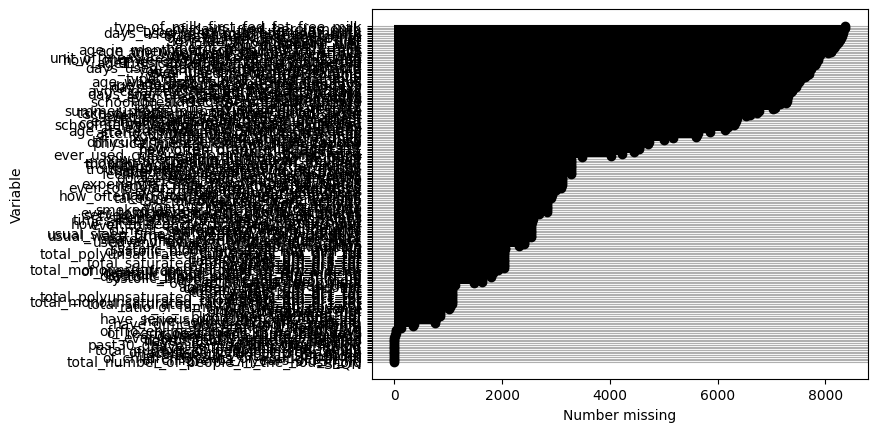

In [12]:
nhanes_raw_df.missing.missing_variable_plot()

## Selección de columnas

In [13]:
nhanes_selected = nhanes_raw_df[[
  'general_health_condition',
  'age_in_years_at_screening',
  'gender',
  'current_selfreported_height_inches',
  'current_selfreported_weight_pounds',
  'doctor_told_you_have_diabetes',
  '60_sec_pulse30_sec_pulse2',
  'total_cholesterol_mgdl',
]].rename(
  columns={
    'general_health_condition': 'health_condition',
    'age_in_years_at_screening': 'age',
    'current_selfreported_height_inches': 'height',
    'current_selfreported_weight_pounds': 'weight',
    'doctor_told_you_have_diabetes': 'diabetes',
    '60_sec_pulse30_sec_pulse2': 'pulse',
    'total_cholesterol_mgdl': 'cholesterol'
  },
)
nhanes_selected.head()

,health_condition,age,gender,height,weight,diabetes,pulse,cholesterol
0,NaN,2.0,Female,NaN,NaN,0,NaN,NaN
1,NaN,2.0,Male,NaN,NaN,0,NaN,NaN
2,Good,66.0,Female,63.0,165.0,0,52.0,157.0
3,Very good,18.0,Male,68.0,145.0,0,82.0,148.0
4,Good,13.0,Male,NaN,NaN,0,100.0,189.0


## Analisis variables seleccionadas

### Analisis columnas

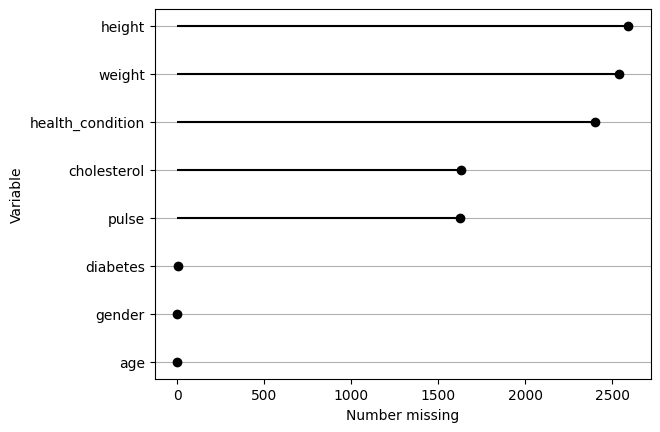

In [14]:
nhanes_selected.missing.missing_variable_plot()

In [15]:
nhanes_selected.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,health_condition,2402,8366,28.711451
1,age,0,8366,0.000000
2,gender,0,8366,0.000000
3,height,2590,8366,30.958642
4,weight,2538,8366,30.337079
5,diabetes,4,8366,0.047813
6,pulse,1624,8366,19.411905
7,cholesterol,1628,8366,19.459718


### Analisis filas

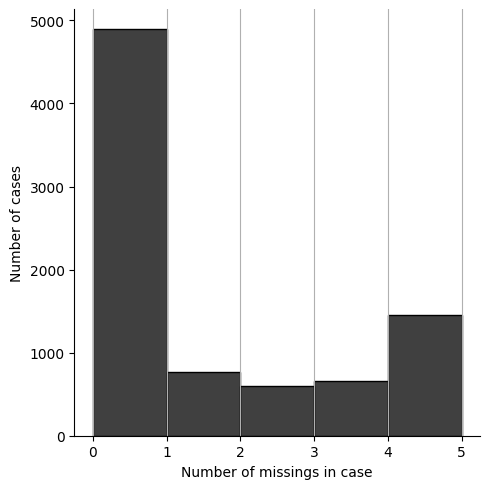

In [16]:
nhanes_selected.missing.missing_case_plot()

In [17]:
nhanes_selected.missing.missing_case_summary()

,case,n_missing,pct_missing
0,0,5,50.0
1,1,5,50.0
2,2,0,0.0
3,3,0,0.0
4,4,2,20.0
...,...,...,...
8361,8361,1,10.0
8362,8362,0,0.0
8363,8363,0,0.0
8364,8364,2,20.0


<Axes: >

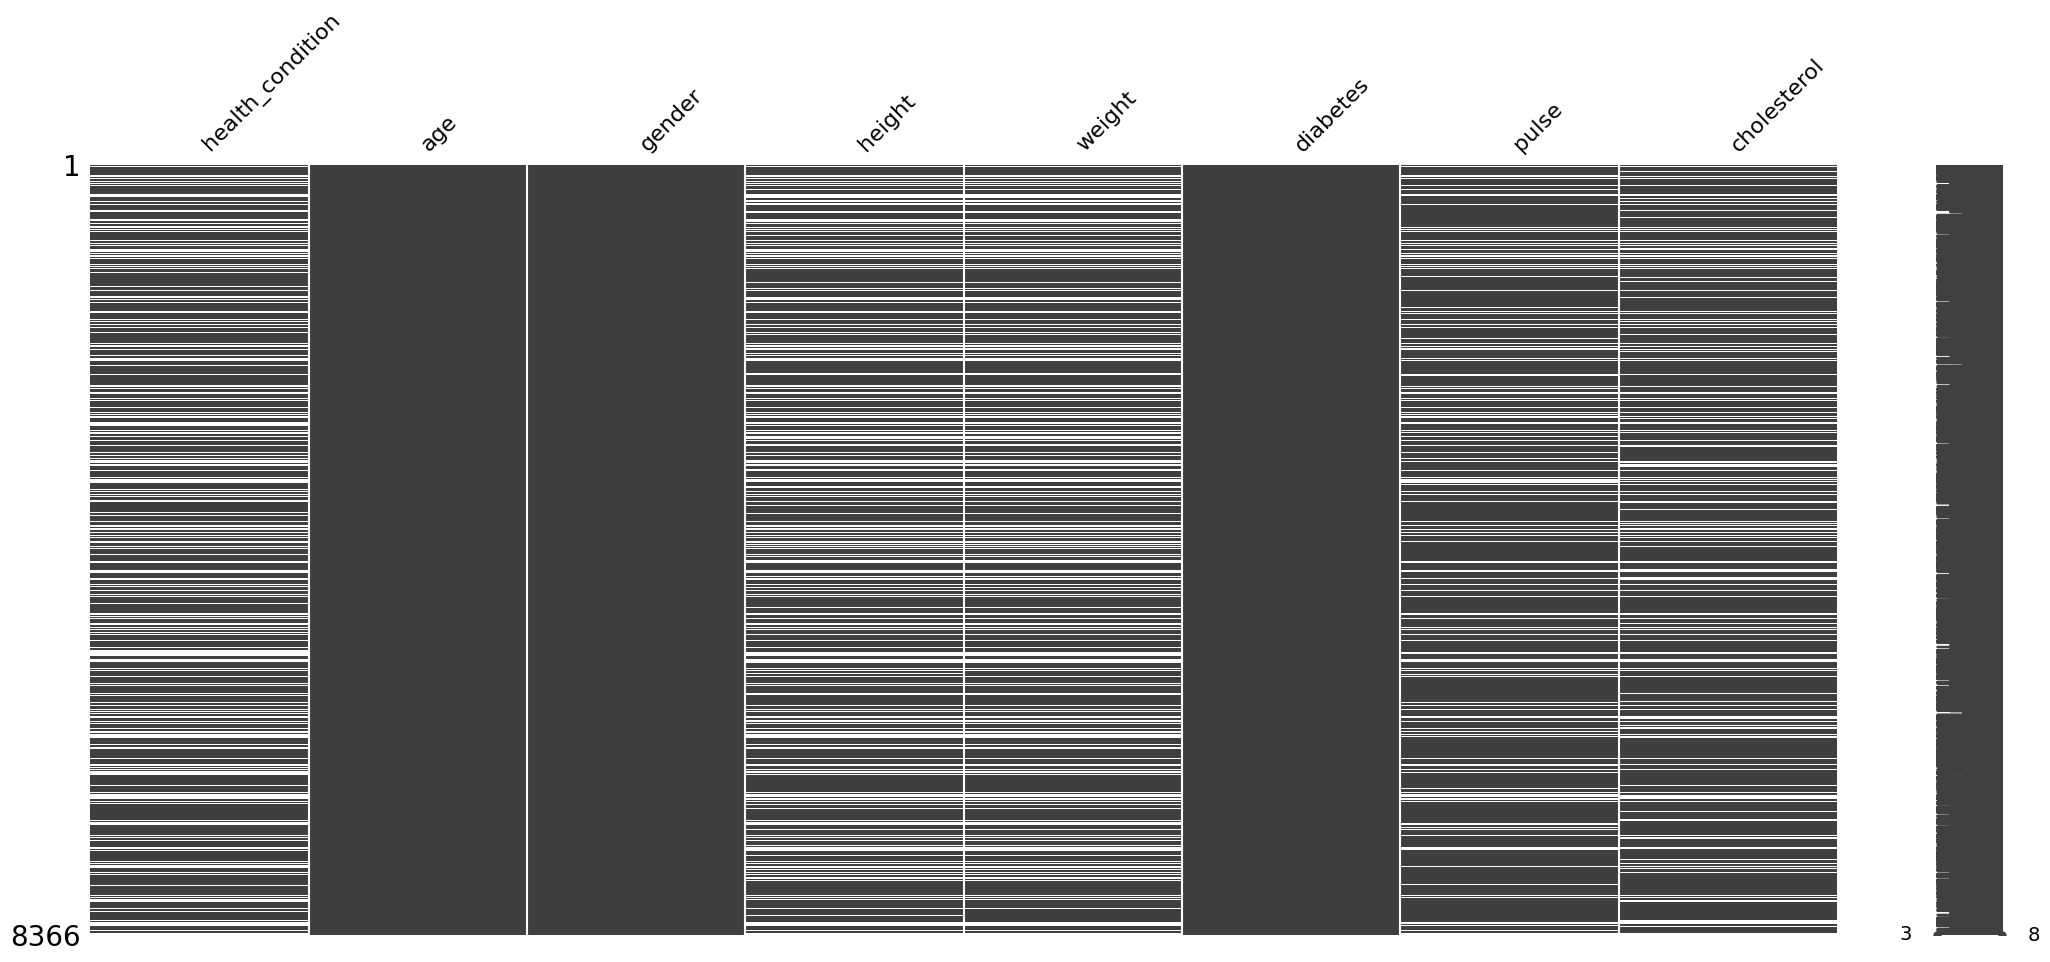

In [18]:
msno.matrix(df = nhanes_selected)

<Axes: >

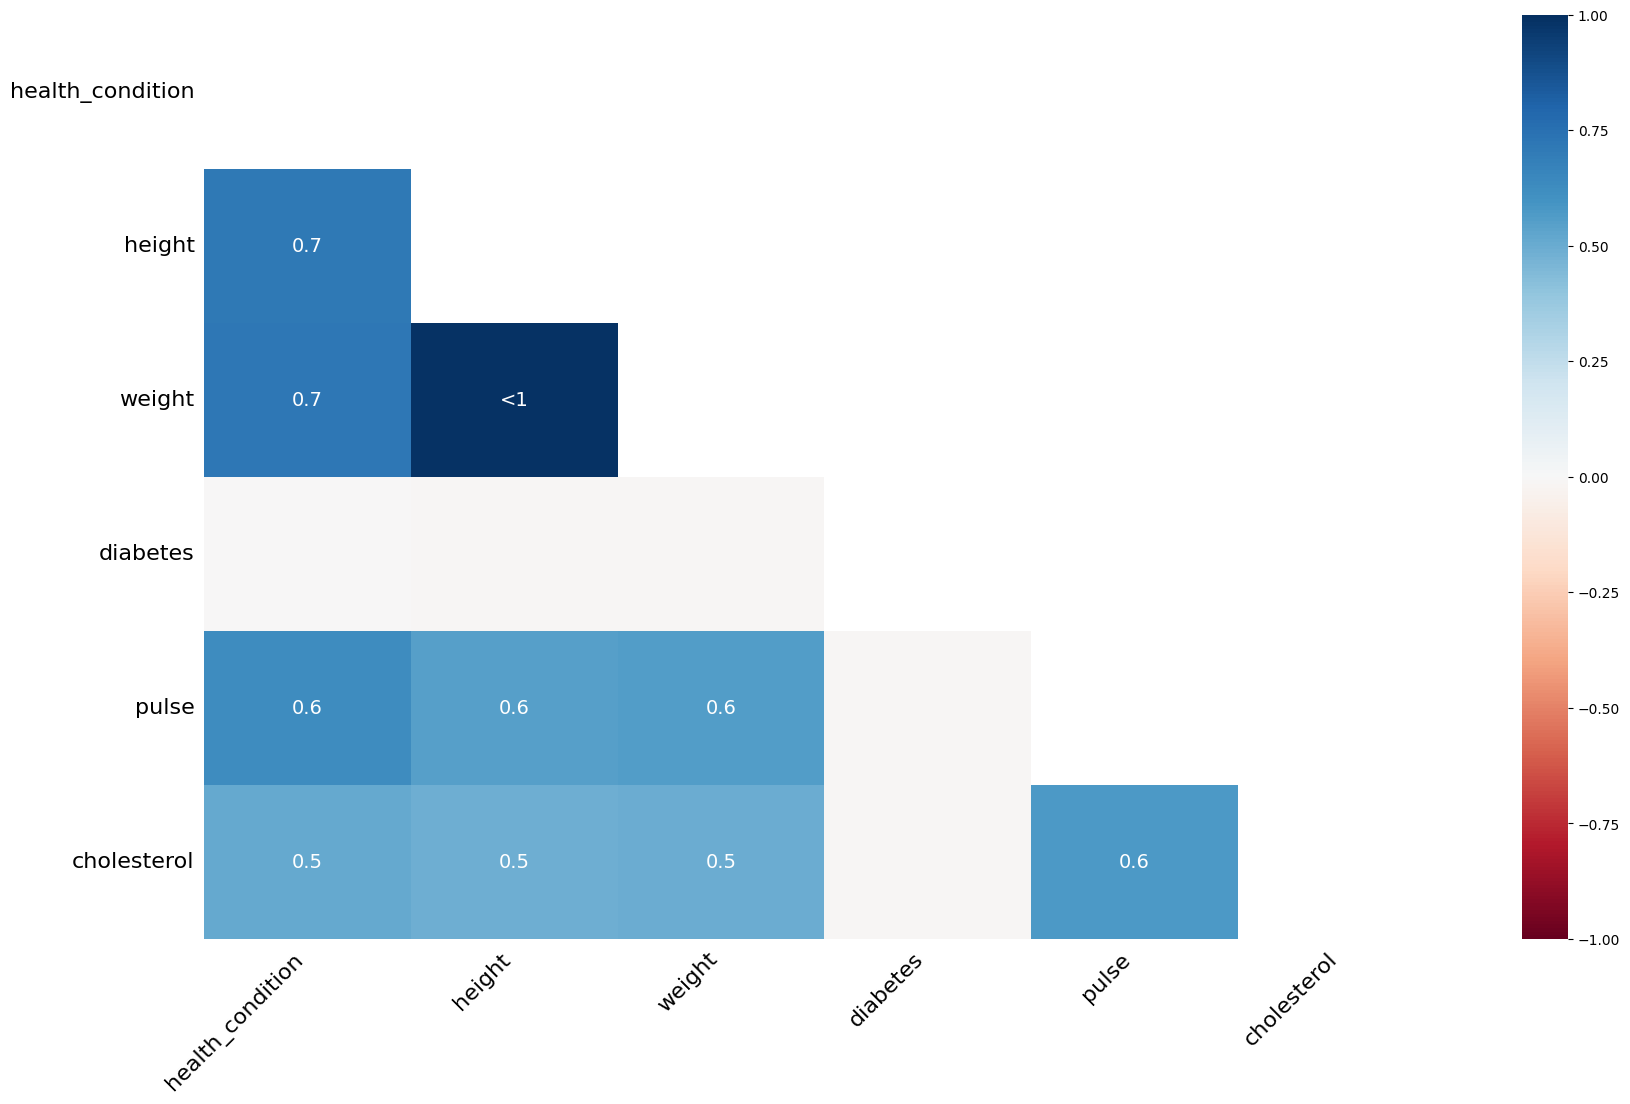

In [19]:
msno.heatmap(df = nhanes_selected)

# Mecanismos para obtener una fuente de datos completa

## Metodo info():
Determina la cantidad de registros, los tipos de variables y la cantidad de datos no nulos

In [20]:
nhanes_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   health_condition  5964 non-null   str    
 1   age               8366 non-null   float64
 2   gender            8366 non-null   str    
 3   height            5776 non-null   float64
 4   weight            5828 non-null   float64
 5   diabetes          8362 non-null   str    
 6   pulse             6742 non-null   float64
 7   cholesterol       6738 non-null   float64
dtypes: float64(5), str(3)
memory usage: 523.0 KB


## Comportamiento estadistico de las variables

El metodo **describe()** calcula para variables numericas media, mediana, desciación estandar y cuartiles.

Para variables categoricas moda y frecuencia de la moda.

In [21]:
nhanes_selected.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
health_condition,5964,5,Good,2454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,8366.0,NaN,NaN,NaN,35.830026,24.905061,1.0,12.0,33.0,59.0,80.0
gender,8366,2,Female,4272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,5776.0,NaN,NaN,NaN,272.22403,1414.518896,49.0,63.0,66.0,70.0,9999.0
weight,5828.0,NaN,NaN,NaN,350.99571,1280.908078,72.0,145.0,171.5,208.0,9999.0
diabetes,8362,3,0,7334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pulse,6742.0,NaN,NaN,NaN,73.749926,12.380546,34.0,66.0,72.0,82.0,136.0
cholesterol,6738.0,NaN,NaN,NaN,179.894627,40.602248,76.0,151.0,176.0,204.0,446.0


### Comportamiento variables categoricas

In [22]:
nhanes_selected.describe(include='object').transpose()

,count,unique,top,freq
health_condition,5964,5,Good,2454
gender,8366,2,Female,4272
diabetes,8362,3,0,7334


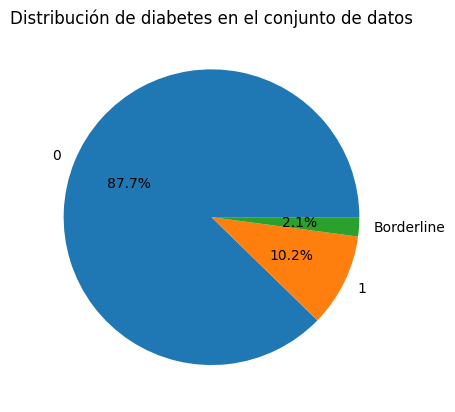

In [23]:
plt.pie(
  x = nhanes_selected.diabetes.value_counts(),
  labels = nhanes_selected.diabetes.value_counts().index,
  autopct='%1.1f%%'
)
plt.title('Distribución de diabetes en el conjunto de datos')
plt.show()

### Comportamiento variables numericos

In [24]:
nhanes_selected.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,8366.0,35.830026,24.905061,1.0,12.0,33.0,59.0,80.0
height,5776.0,272.224030,1414.518896,49.0,63.0,66.0,70.0,9999.0
weight,5828.0,350.995710,1280.908078,72.0,145.0,171.5,208.0,9999.0
pulse,6742.0,73.749926,12.380546,34.0,66.0,72.0,82.0,136.0
cholesterol,6738.0,179.894627,40.602248,76.0,151.0,176.0,204.0,446.0


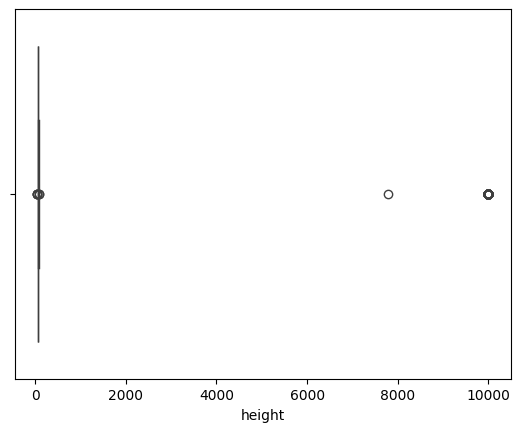

In [25]:
sns.boxplot(data=nhanes_selected, x='height')
plt.show()

## Desenmascarar datos nulos

In [ ]:
nhanes_selected = nhanes_selected.replace({
  'height': { 9999: np.nan, 7777: np.nan },
  'weight': { 9999: np.nan, 7777: np.nan },
  'diabetes': { 'Borderline': np.nan }
})

nhanes_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   health_condition  5964 non-null   str    
 1   age               8366 non-null   float64
 2   gender            8366 non-null   str    
 3   height            5656 non-null   float64
 4   weight            5724 non-null   float64
 5   diabetes          8187 non-null   str    
 6   pulse             6742 non-null   float64
 7   cholesterol       6738 non-null   float64
dtypes: float64(5), str(3)
memory usage: 523.0 KB


### Reanalizar variables

In [27]:
nhanes_selected.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,8366.0,35.830026,24.905061,1.0,12.0,33.0,59.0,80.0
height,5656.0,66.249646,4.154477,49.0,63.0,66.0,69.0,82.0
weight,5724.0,178.805556,48.688953,72.0,145.0,170.0,205.0,484.0
pulse,6742.0,73.749926,12.380546,34.0,66.0,72.0,82.0,136.0
cholesterol,6738.0,179.894627,40.602248,76.0,151.0,176.0,204.0,446.0


In [28]:
nhanes_selected.describe(include='object').transpose()

,count,unique,top,freq
health_condition,5964,5,Good,2454
gender,8366,2,Female,4272
diabetes,8187,2,0,7334


### Grafica de matrix de nulos con diabetes

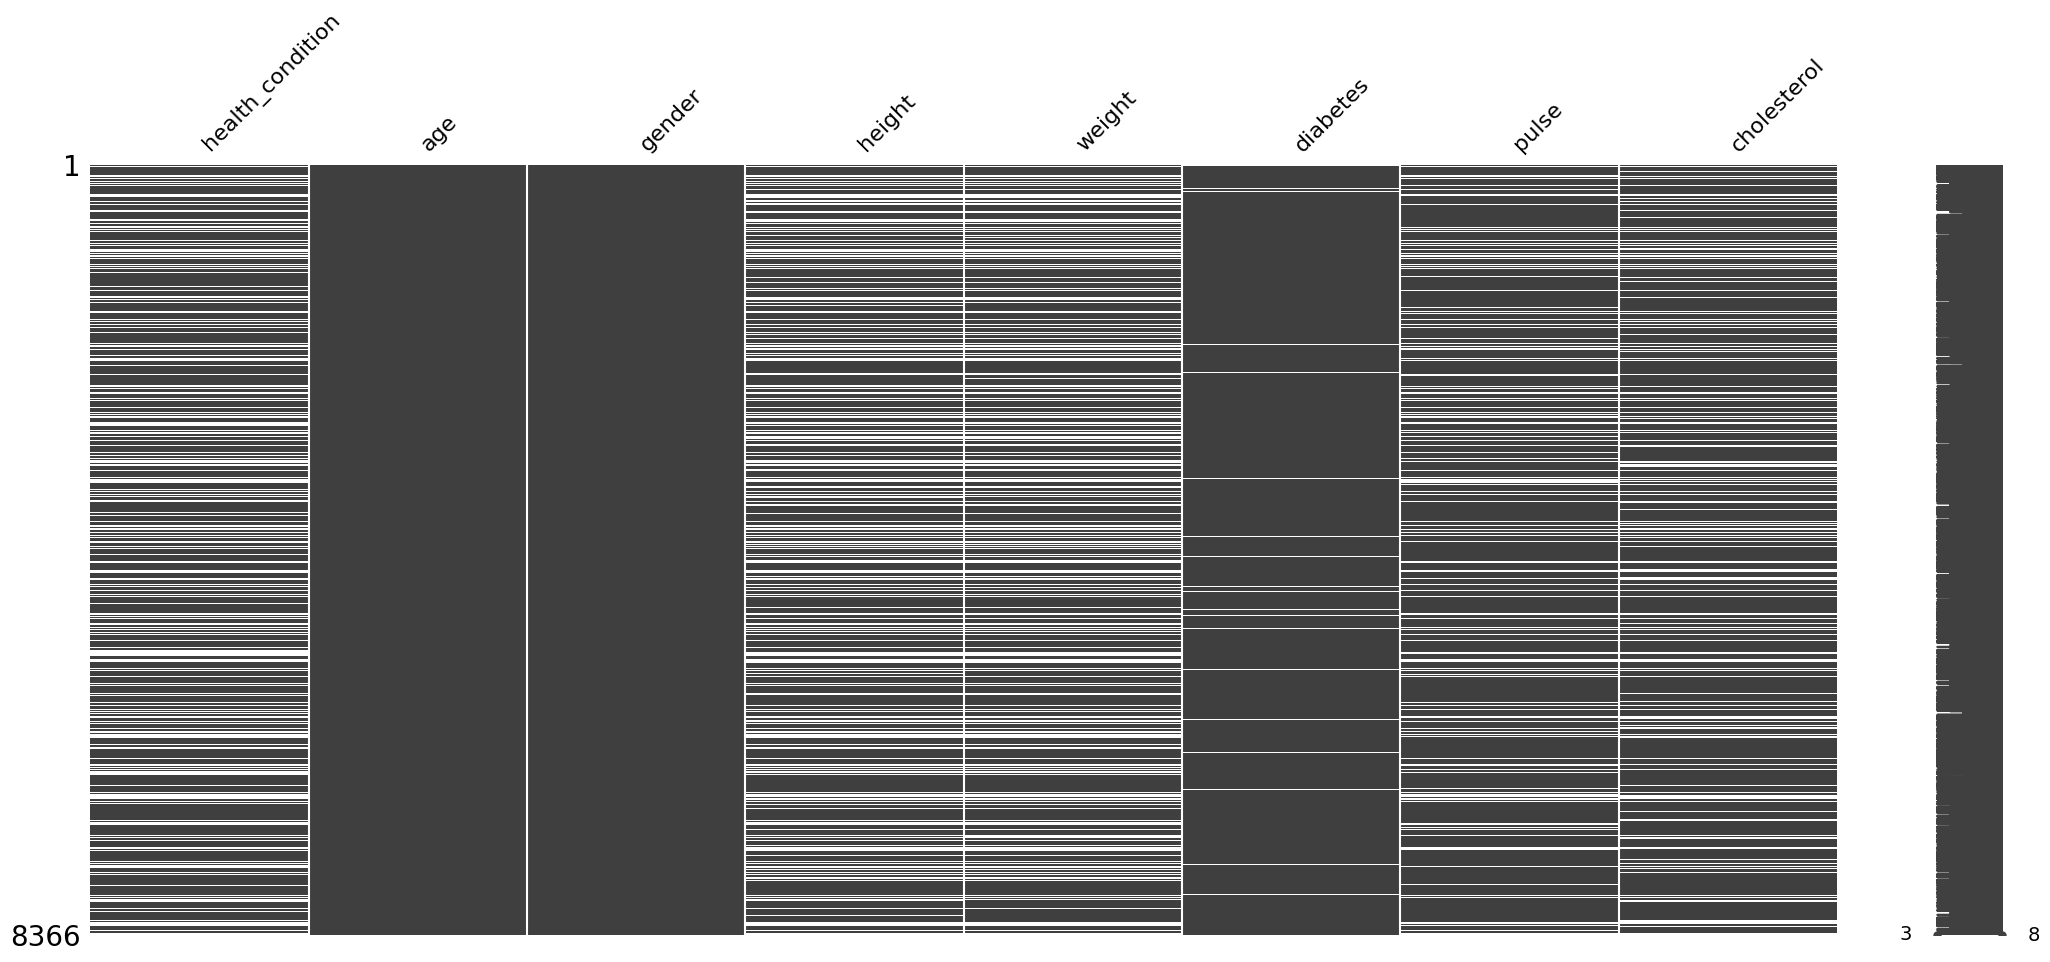

In [29]:
msno.matrix(df = nhanes_selected)
plt.show()

## Eliminar datos que tengan diabetes null

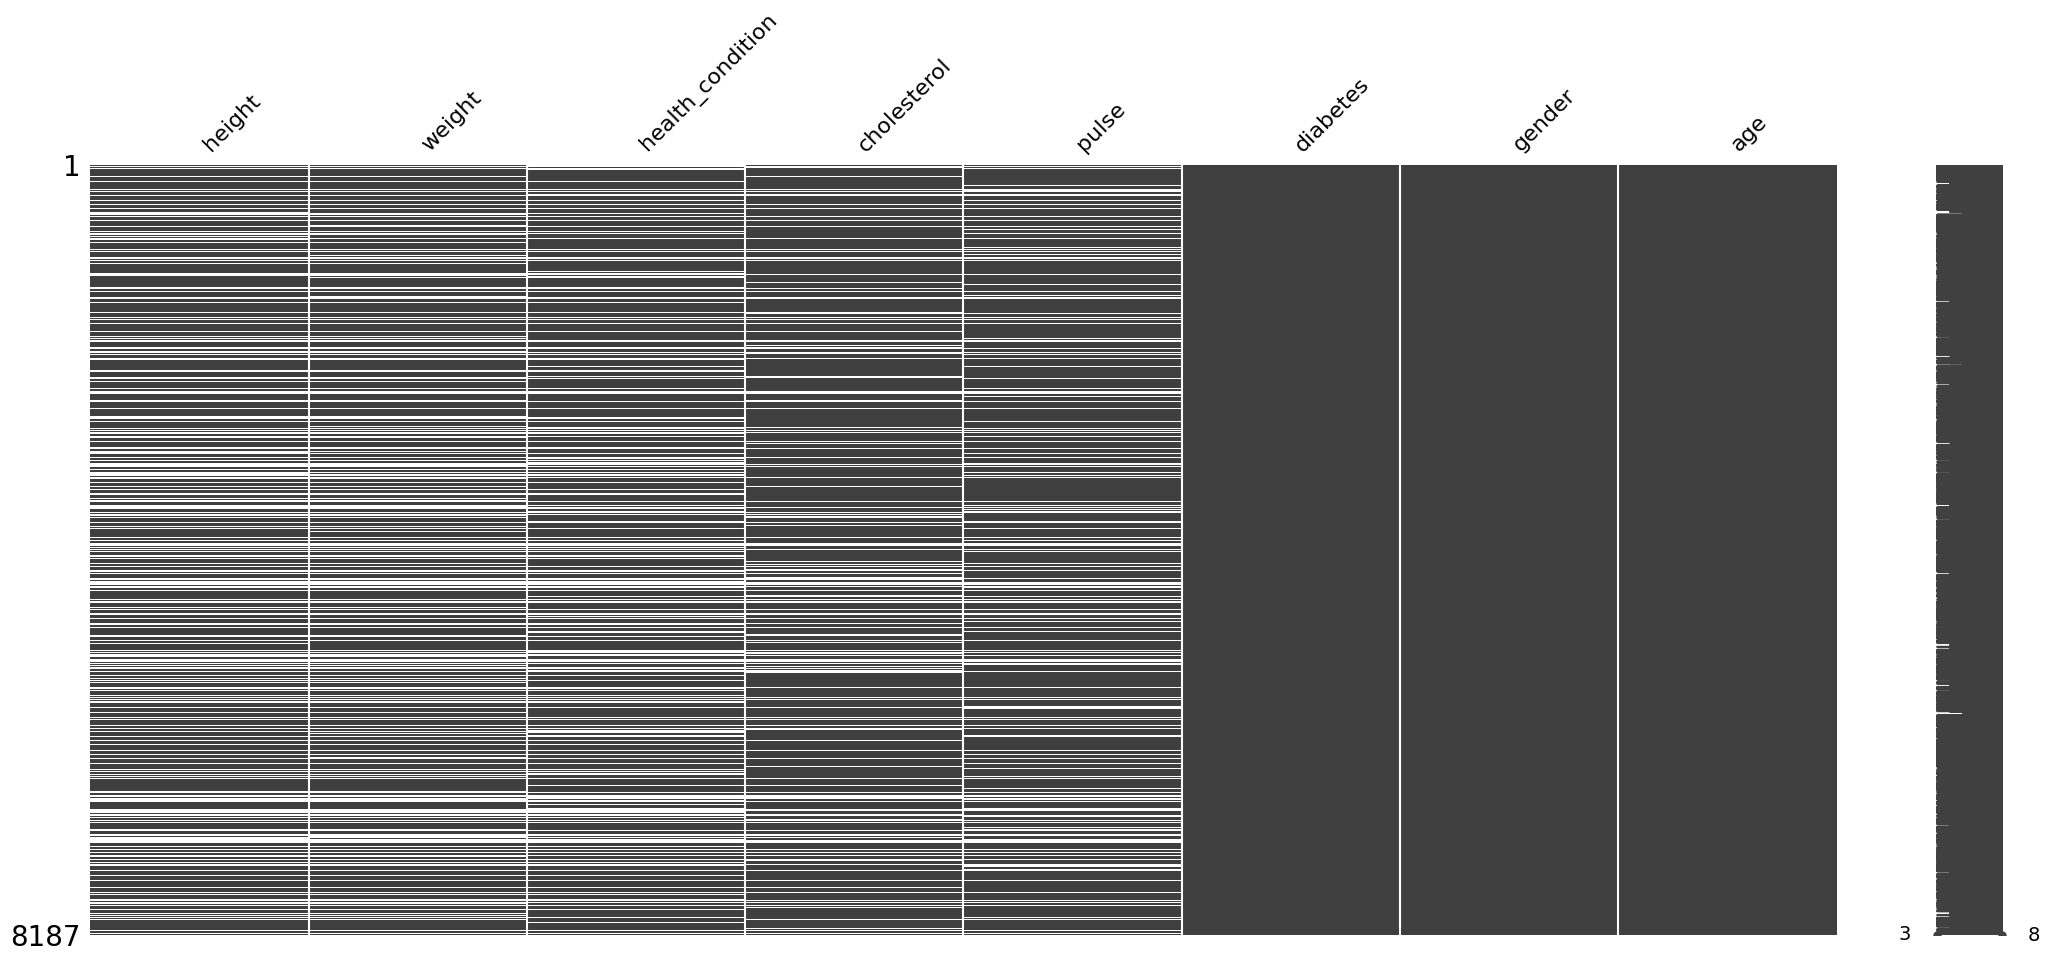

In [30]:
nhanes_df = (
  nhanes_selected.missing.sort_variables_by_missingness().
  dropna(subset=['diabetes'], how='any')
)

msno.matrix(df = nhanes_df)
plt.show()

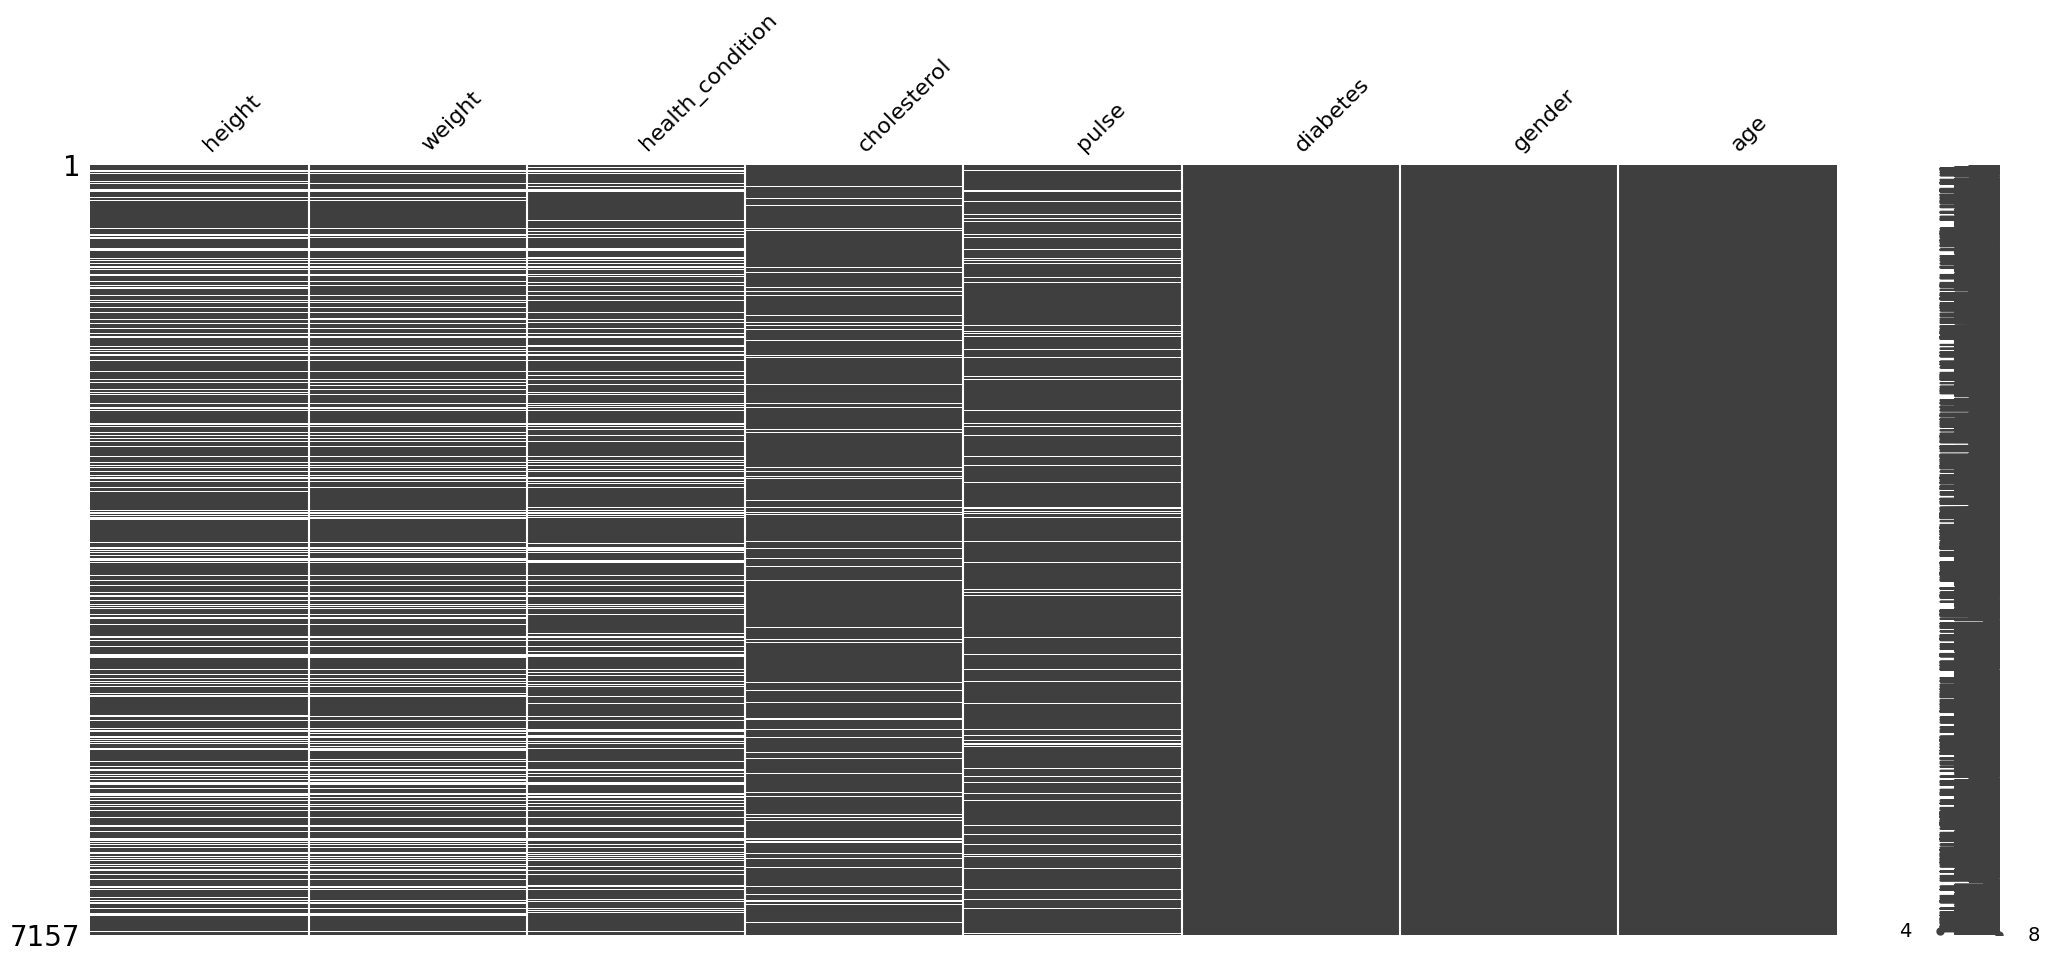

In [31]:
nhanes_df.dropna(subset=['height', 'weight', 'health_condition', 'cholesterol', 'pulse'], how='all', inplace=True)

msno.matrix(df = nhanes_df)
plt.show()

# Imputaciones de datos

In [32]:
nhanes_df.info()

<class 'pandas.DataFrame'>
Index: 7157 entries, 2 to 8365
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height            5488 non-null   float64
 1   weight            5553 non-null   float64
 2   health_condition  5797 non-null   str    
 3   cholesterol       6565 non-null   float64
 4   pulse             6570 non-null   float64
 5   diabetes          7157 non-null   str    
 6   gender            7157 non-null   str    
 7   age               7157 non-null   float64
dtypes: float64(5), str(3)
memory usage: 503.2 KB


## Imputación por Medidas de Tendencia Central
- Si la variable es categórica, utilizamos la moda como mecanismo de imputación.
- Si la variable es numérica, utilizamos la media o la mediana como mecanismo de imputación. Si se percibe un **sesgo**, el mejor camino es la *mediana*.

In [33]:
nhanes_df_copy = nhanes_df.copy()
nhanes_df_copy['height'] = nhanes_df_copy['height'].fillna(nhanes_df_copy['height'].mean().round())
nhanes_df_copy

,height,weight,health_condition,cholesterol,pulse,diabetes,gender,age
2,63.0,165.0,Good,157.0,52.0,0,Female,66.0
3,68.0,145.0,Very good,148.0,82.0,0,Male,18.0
4,66.0,NaN,Good,189.0,100.0,0,Male,13.0
6,62.0,200.0,NaN,176.0,74.0,0,Female,75.0
7,69.0,142.0,Very good,238.0,62.0,0,Male,56.0
...,...,...,...,...,...,...,...,...
8359,72.0,180.0,Excellent,201.0,96.0,0,Male,33.0
8362,65.0,218.0,Fair or,182.0,78.0,0,Male,42.0
8363,66.0,150.0,Good,172.0,78.0,0,Female,41.0
8364,66.0,NaN,Very good,150.0,74.0,0,Female,14.0


In [47]:
nhanes_df_copy.info()

<class 'pandas.DataFrame'>
Index: 7157 entries, 2 to 8365
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height            7157 non-null   float64
 1   weight            5553 non-null   float64
 2   health_condition  5797 non-null   str    
 3   cholesterol       6565 non-null   float64
 4   pulse             6570 non-null   float64
 5   diabetes          7157 non-null   str    
 6   gender            7157 non-null   str    
 7   age               7157 non-null   float64
dtypes: float64(5), str(3)
memory usage: 503.2 KB


### Grafico de sombras
Pone True donde se llenó un nulo

<Axes: xlabel='height', ylabel='weight'>

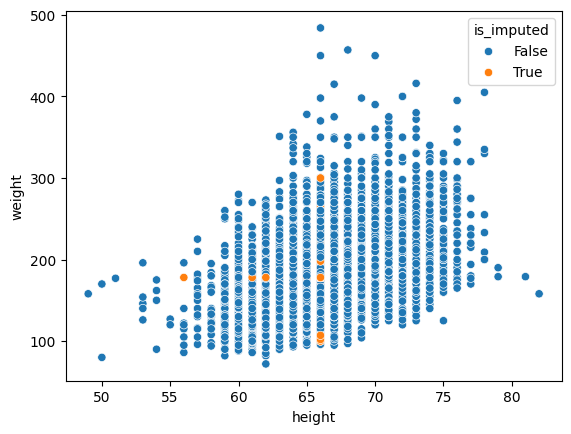

In [36]:
# Calcular valores de imputación
height_mean = nhanes_df['height'].mean().round()
weight_mean = nhanes_df['weight'].mean().round()

# Seleccionar columnas, crear shadow matrix e imputar
nhanes_shadow_imputed = (
  nhanes_df
  .select(columns=['height', 'weight'])
  .missing.bind_shadow_matrix(True, False, suffix='_imp')
  .assign(
    height=lambda df: df['height'].fillna(height_mean),
    weight=lambda df: df['weight'].fillna(weight_mean),
  )
  .missing
  .scatter_imputation_plot(x='height', y='weight')
)

nhanes_shadow_imputed

## Imputación por Modelo de Regresion
- Imputación por modelo de vecindad
- Imputación MICE

### shadow_imputation_plot

In [59]:
from IPython.display import display

def shadow_imputation_plot(df, x='height', y='weight'):
  shadow_matrix = pd.concat(
    [
      df,
      nhanes_df.missing.create_shadow_matrix(True, False, suffix='_imp', only_missing=True)
    ],
    axis=1
  )

  display(shadow_matrix)

  shadow_matrix.missing.scatter_imputation_plot(x=x, y=y)
  plt.show()

### Transformación (Codificación) de variables categóricas

In [40]:
categorical_columns = nhanes_df.select_dtypes(include=['object', 'string']).columns

categorical_transformer = (
  sklearn.compose
  .make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(), categorical_columns),
    remainder='passthrough'
  )
)

categorical_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.

In [43]:
nhanes_transformed_df = (
  pd.DataFrame(
    categorical_transformer.fit_transform(nhanes_df),
    columns=categorical_transformer.get_feature_names_out(),
    index=nhanes_df.index
  )
  .rename(columns=lambda x: x.replace('ordinalencoder__', ''))
  .rename(columns=lambda x: x.replace('remainder__', ''))
)

nhanes_transformed_df

,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0
4,2.0,0.0,1.0,NaN,NaN,189.0,100.0,13.0
6,NaN,0.0,0.0,62.0,200.0,176.0,74.0,75.0
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0
...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0
8364,4.0,0.0,0.0,NaN,NaN,150.0,74.0,14.0


### 1. Imputación por vecindad

In [44]:
knn_imputer = sklearn.impute.KNNImputer()

nhanes_knn_df = pd.DataFrame(
  knn_imputer.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

nhanes_knn_df.info()

<class 'pandas.DataFrame'>
Index: 7157 entries, 2 to 8365
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   health_condition  7157 non-null   float64
 1   diabetes          7157 non-null   float64
 2   gender            7157 non-null   float64
 3   height            7157 non-null   float64
 4   weight            7157 non-null   float64
 5   cholesterol       7157 non-null   float64
 6   pulse             7157 non-null   float64
 7   age               7157 non-null   float64
dtypes: float64(8)
memory usage: 503.2 KB


,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age,height_imp,weight_imp,health_condition_imp,cholesterol_imp,pulse_imp
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0,False,False,False,False,False
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0,False,False,False,False,False
4,2.0,0.0,1.0,69.0,130.0,189.0,100.0,13.0,True,True,False,False,False
6,2.0,0.0,0.0,62.0,200.0,176.0,74.0,75.0,False,False,True,False,False
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0,False,False,False,False,False
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0,False,False,False,False,False
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0,False,False,False,False,False
8364,4.0,0.0,0.0,71.0,159.0,150.0,74.0,14.0,True,True,False,False,False


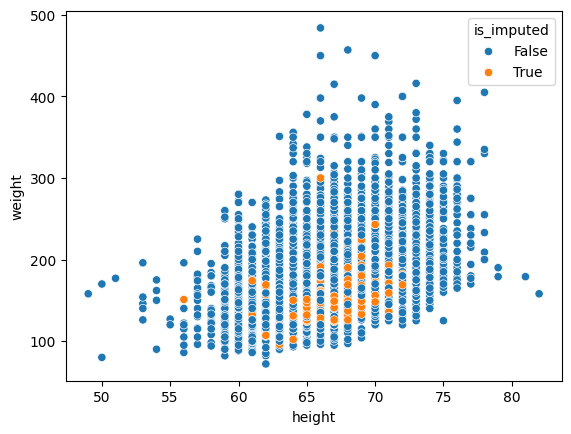

In [60]:
shadow_imputation_plot(nhanes_knn_df)

### 2. Imputación MICE

In [50]:
# Librerias necesarias
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer

#### LinearRegression

In [62]:
mice_imputer_linear = sklearn.impute.IterativeImputer(
  estimator=LinearRegression(),
  initial_strategy='mean',
  max_iter=10,
)

nhanes_mice_linear_df = pd.DataFrame(
  mice_imputer_linear.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

nhanes_mice_linear_df

,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0
4,2.0,0.0,1.0,70.0,200.0,189.0,100.0,13.0
6,2.0,0.0,0.0,62.0,200.0,176.0,74.0,75.0
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0
...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0
8364,4.0,0.0,0.0,64.0,159.0,150.0,74.0,14.0


,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age,height_imp,weight_imp,health_condition_imp,cholesterol_imp,pulse_imp
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0,False,False,False,False,False
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0,False,False,False,False,False
4,2.0,0.0,1.0,70.0,200.0,189.0,100.0,13.0,True,True,False,False,False
6,2.0,0.0,0.0,62.0,200.0,176.0,74.0,75.0,False,False,True,False,False
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0,False,False,False,False,False
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0,False,False,False,False,False
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0,False,False,False,False,False
8364,4.0,0.0,0.0,64.0,159.0,150.0,74.0,14.0,True,True,False,False,False


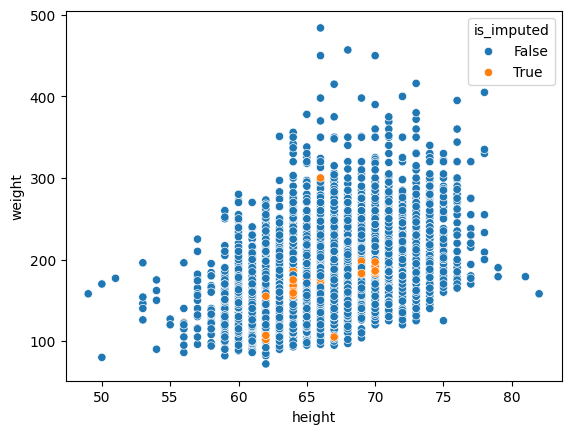

In [61]:
shadow_imputation_plot(nhanes_mice_linear_df)

#### DecisionTreeRegressor

In [66]:
mice_imputer_dcr = sklearn.impute.IterativeImputer(
  estimator=DecisionTreeRegressor(random_state=123),
  initial_strategy='mean',
  max_iter=10,
)

nhanes_mice_dcr_df = pd.DataFrame(
  mice_imputer_dcr.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

nhanes_mice_dcr_df

,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0
4,2.0,0.0,1.0,69.0,310.0,189.0,100.0,13.0
6,2.0,0.0,0.0,62.0,200.0,176.0,74.0,75.0
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0
...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0
8364,4.0,0.0,0.0,59.0,110.0,150.0,74.0,14.0


,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age,height_imp,weight_imp,health_condition_imp,cholesterol_imp,pulse_imp
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0,False,False,False,False,False
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0,False,False,False,False,False
4,2.0,0.0,1.0,69.0,310.0,189.0,100.0,13.0,True,True,False,False,False
6,2.0,0.0,0.0,62.0,200.0,176.0,74.0,75.0,False,False,True,False,False
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0,False,False,False,False,False
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0,False,False,False,False,False
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0,False,False,False,False,False
8364,4.0,0.0,0.0,59.0,110.0,150.0,74.0,14.0,True,True,False,False,False


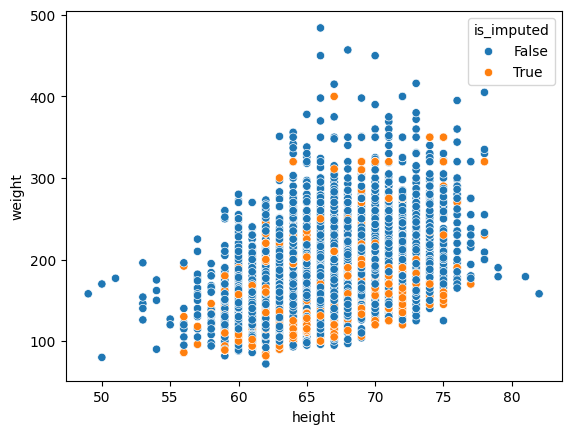

In [67]:
shadow_imputation_plot(nhanes_mice_dcr_df)

#### RandomForestRegressor

In [68]:
mice_imputer_rfr = sklearn.impute.IterativeImputer(
  estimator=RandomForestRegressor(random_state=123),
  initial_strategy='mean',
  max_iter=10,
)

nhanes_mice_rfr_df = pd.DataFrame(
  mice_imputer_rfr.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

nhanes_mice_rfr_df

,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0
4,2.0,0.0,1.0,68.0,175.0,189.0,100.0,13.0
6,2.0,0.0,0.0,62.0,200.0,176.0,74.0,75.0
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0
...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0
8364,4.0,0.0,0.0,64.0,144.0,150.0,74.0,14.0


,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age,height_imp,weight_imp,health_condition_imp,cholesterol_imp,pulse_imp
2,2.0,0.0,0.0,63.0,165.0,157.0,52.0,66.0,False,False,False,False,False
3,4.0,0.0,1.0,68.0,145.0,148.0,82.0,18.0,False,False,False,False,False
4,2.0,0.0,1.0,68.0,175.0,189.0,100.0,13.0,True,True,False,False,False
6,2.0,0.0,0.0,62.0,200.0,176.0,74.0,75.0,False,False,True,False,False
7,4.0,0.0,1.0,69.0,142.0,238.0,62.0,56.0,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8359,0.0,0.0,1.0,72.0,180.0,201.0,96.0,33.0,False,False,False,False,False
8362,1.0,0.0,1.0,65.0,218.0,182.0,78.0,42.0,False,False,False,False,False
8363,2.0,0.0,0.0,66.0,150.0,172.0,78.0,41.0,False,False,False,False,False
8364,4.0,0.0,0.0,64.0,144.0,150.0,74.0,14.0,True,True,False,False,False


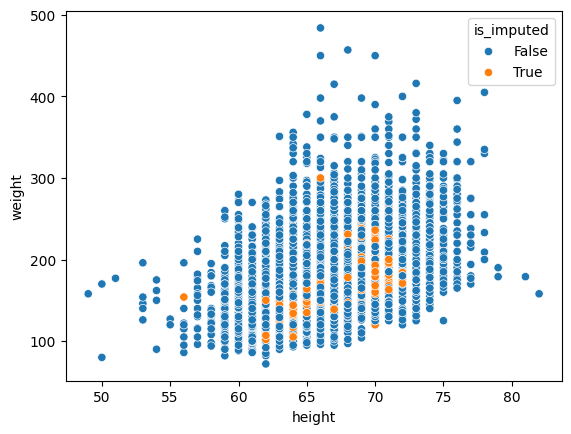

In [74]:
shadow_imputation_plot(nhanes_mice_rfr_df)

### Retornar valores con el transformer

In [ ]:
nhanes_imputed_df = nhanes_mice_rfr_df

nhanes_imputed_df[categorical_columns] = (
  categorical_transformer
  .named_transformers_
  .ordinalencoder
  .inverse_transform(
    X = nhanes_mice_rfr_df[categorical_columns].to_numpy(copy=True)
  )
)

nhanes_imputed_df

,health_condition,diabetes,gender,height,weight,cholesterol,pulse,age
2,Good,0,Female,63.0,165.0,157.0,52.0,66.0
3,Very good,0,Male,68.0,145.0,148.0,82.0,18.0
4,Good,0,Male,68.0,175.0,189.0,100.0,13.0
6,Good,0,Female,62.0,200.0,176.0,74.0,75.0
7,Very good,0,Male,69.0,142.0,238.0,62.0,56.0
...,...,...,...,...,...,...,...,...
8359,Excellent,0,Male,72.0,180.0,201.0,96.0,33.0
8362,Fair or,0,Male,65.0,218.0,182.0,78.0,42.0
8363,Good,0,Female,66.0,150.0,172.0,78.0,41.0
8364,Very good,0,Female,64.0,144.0,150.0,74.0,14.0


# Imputación de Series de Tiempo
- Llenado hacia adelante
- Llenado hacia atrás
- Interpolación por más cercano
- Interpolación lineal
- Interpolación cuadrática
- Interpolación polinomica grado 3
- Interpolación polinomica akima
- Interpolación polinomica pchip

## Dataset airquality

In [88]:
pd.set_option('display.max_rows', 10)

In [89]:
airquality_df = (
  sm.datasets.get_rdataset('airquality')
  .data.clean_names(case_type='snake')
  .add_column('year', 1973)
  .assign(date = lambda df: pd.to_datetime(df[['year', 'month', 'day']]))
  .sort_values(by = 'date')
  .set_index('date')
)

airquality_df

,ozone,solar_r,wind,temp,month,day,year
date,,,,,,,
1973-05-01,41.0,190.0,7.4,67,5,1,1973
1973-05-02,36.0,118.0,8.0,72,5,2,1973
1973-05-03,12.0,149.0,12.6,74,5,3,1973
1973-05-04,18.0,313.0,11.5,62,5,4,1973
1973-05-05,NaN,NaN,14.3,56,5,5,1973
...,...,...,...,...,...,...,...
1973-09-26,30.0,193.0,6.9,70,9,26,1973
1973-09-27,NaN,145.0,13.2,77,9,27,1973
1973-09-28,14.0,191.0,14.3,75,9,28,1973


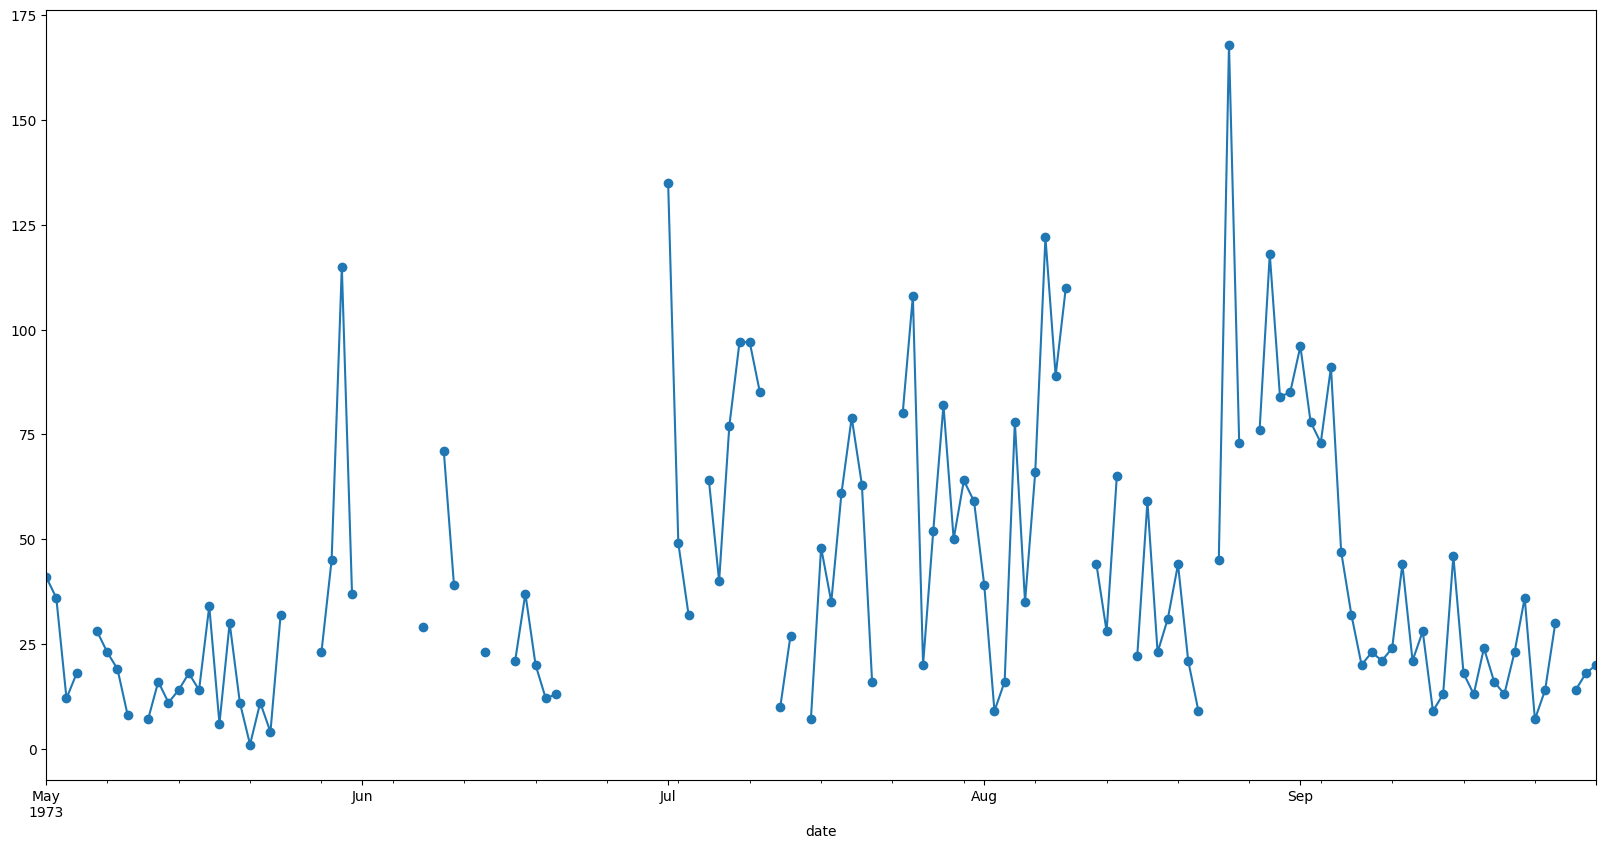

In [90]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
plt.show()

## Metodos Imputación

### Llenado hacia adelante

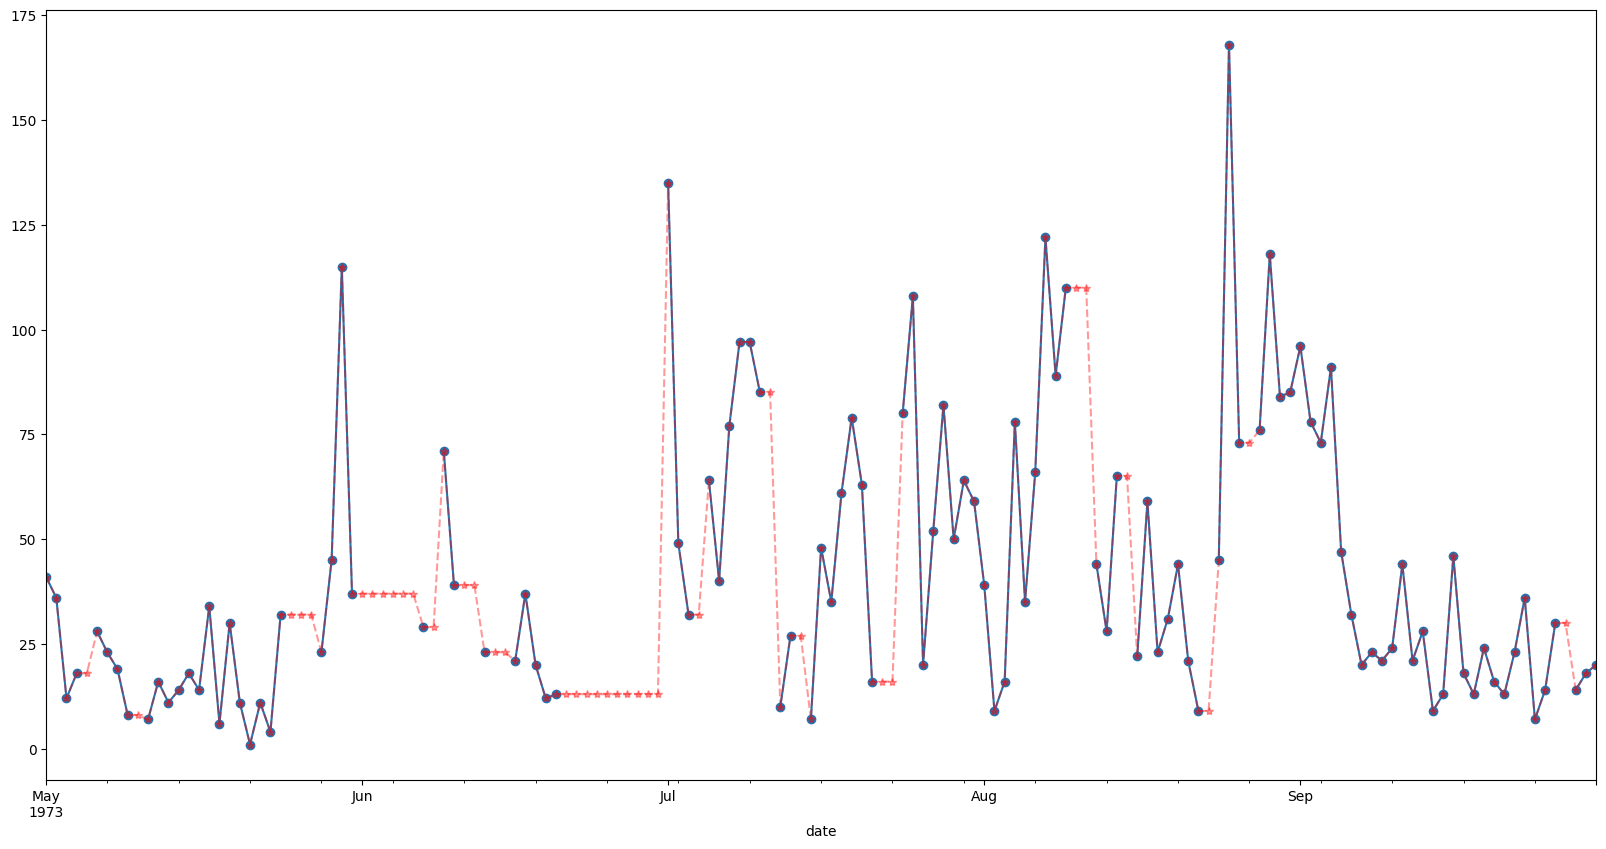

In [91]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.ffill().plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()

### Llenado hacia atras

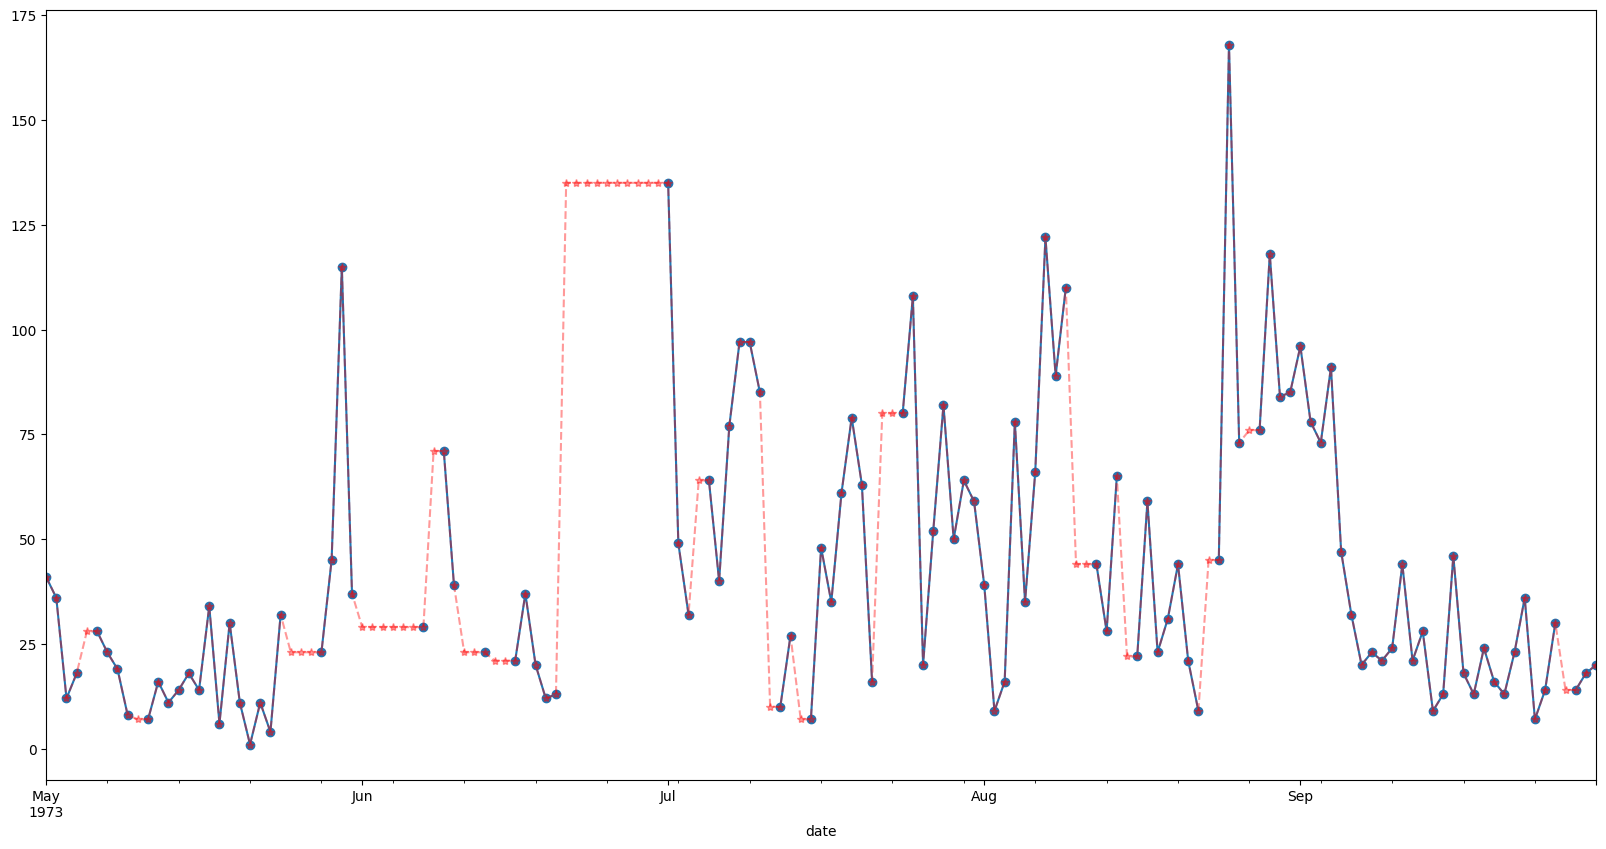

In [92]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.bfill().plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()

### Interpolación por más cercano

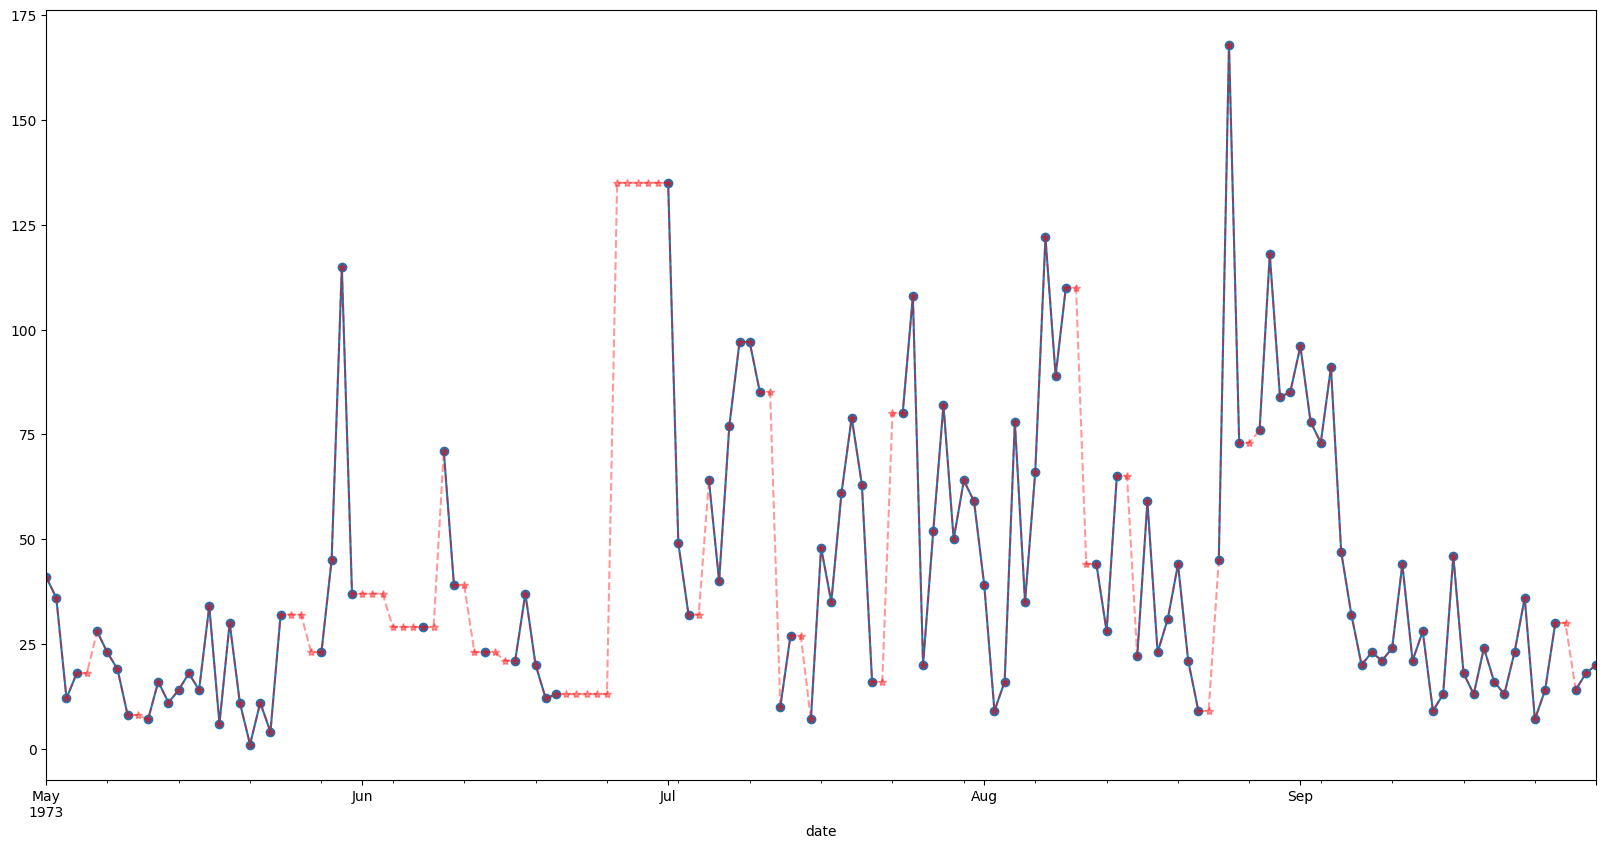

In [93]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.interpolate(
  method='nearest'
).plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()

### Interpolación Lineal

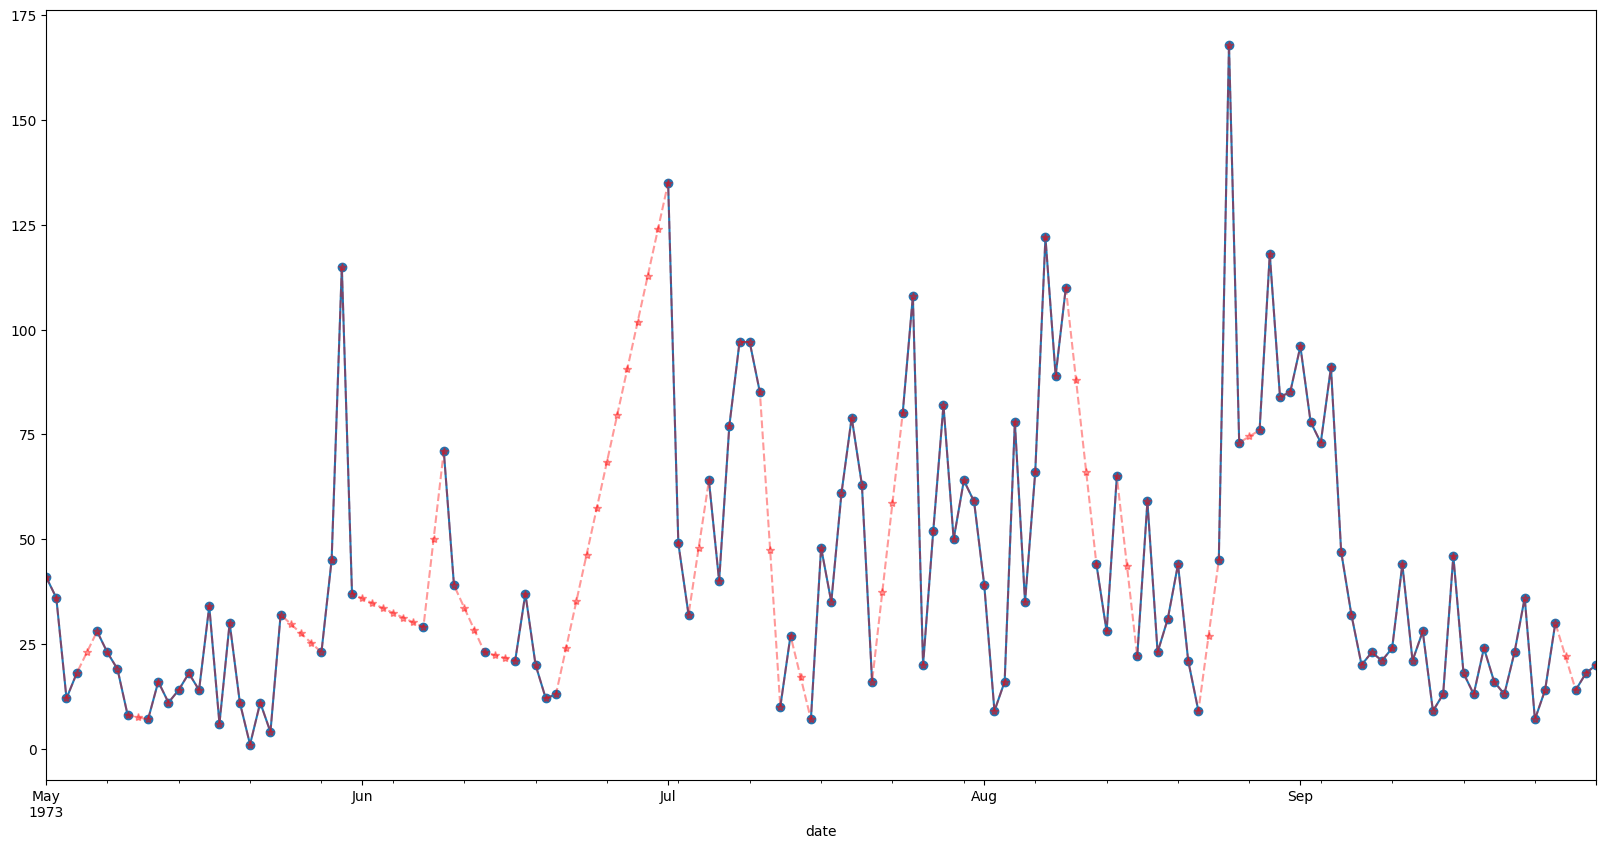

In [94]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.interpolate(
  method='linear'
).plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()

### Interpolación cuadrática

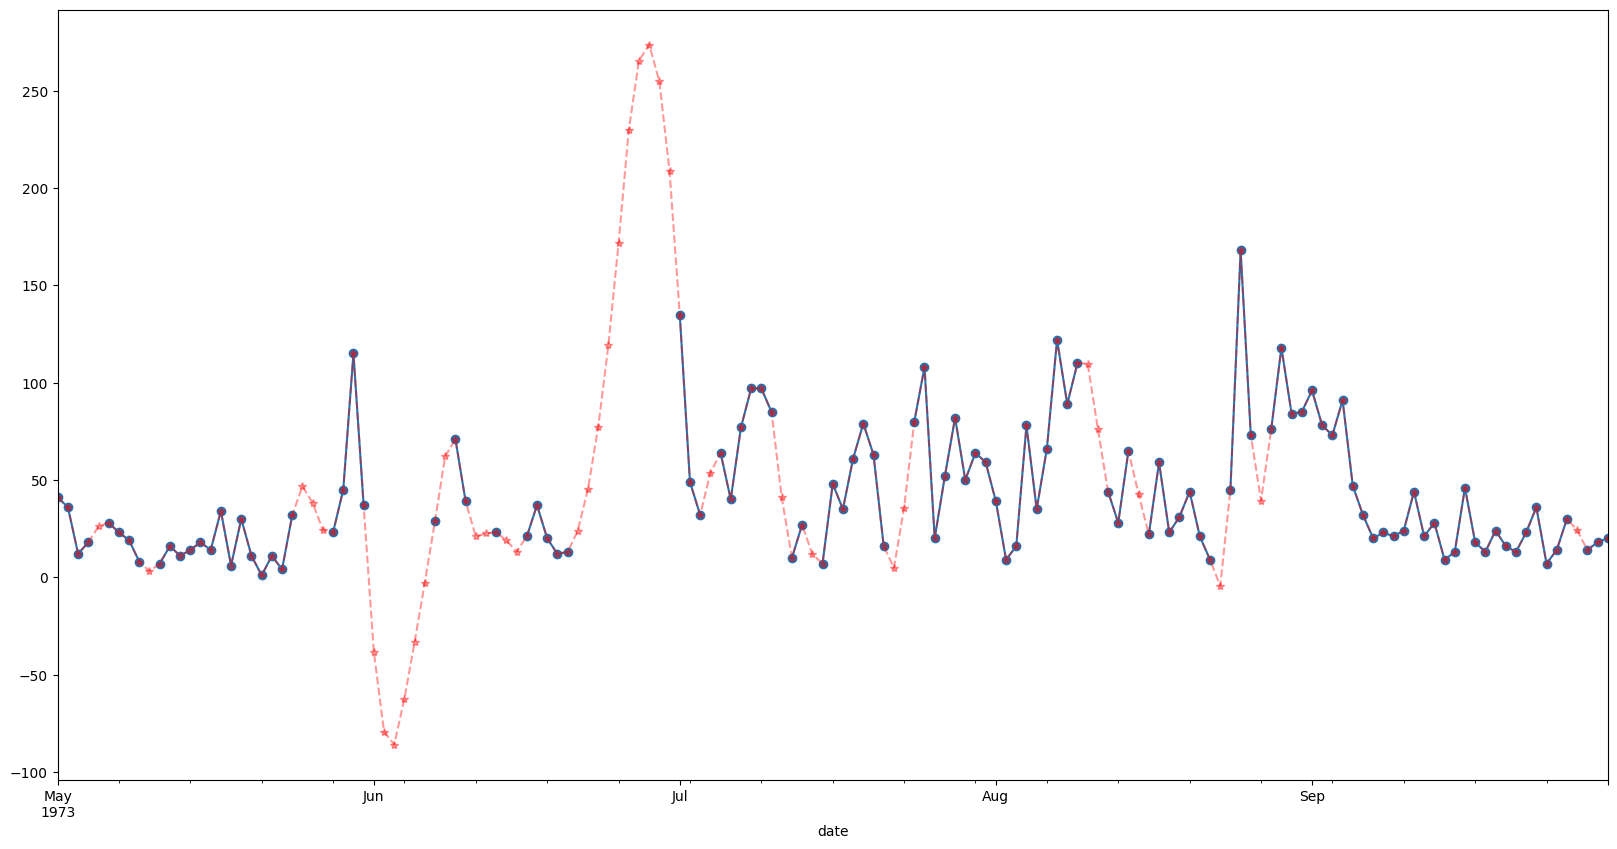

In [95]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.interpolate(
  method='quadratic'
).plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()

### Interpolación polinomica grado 3

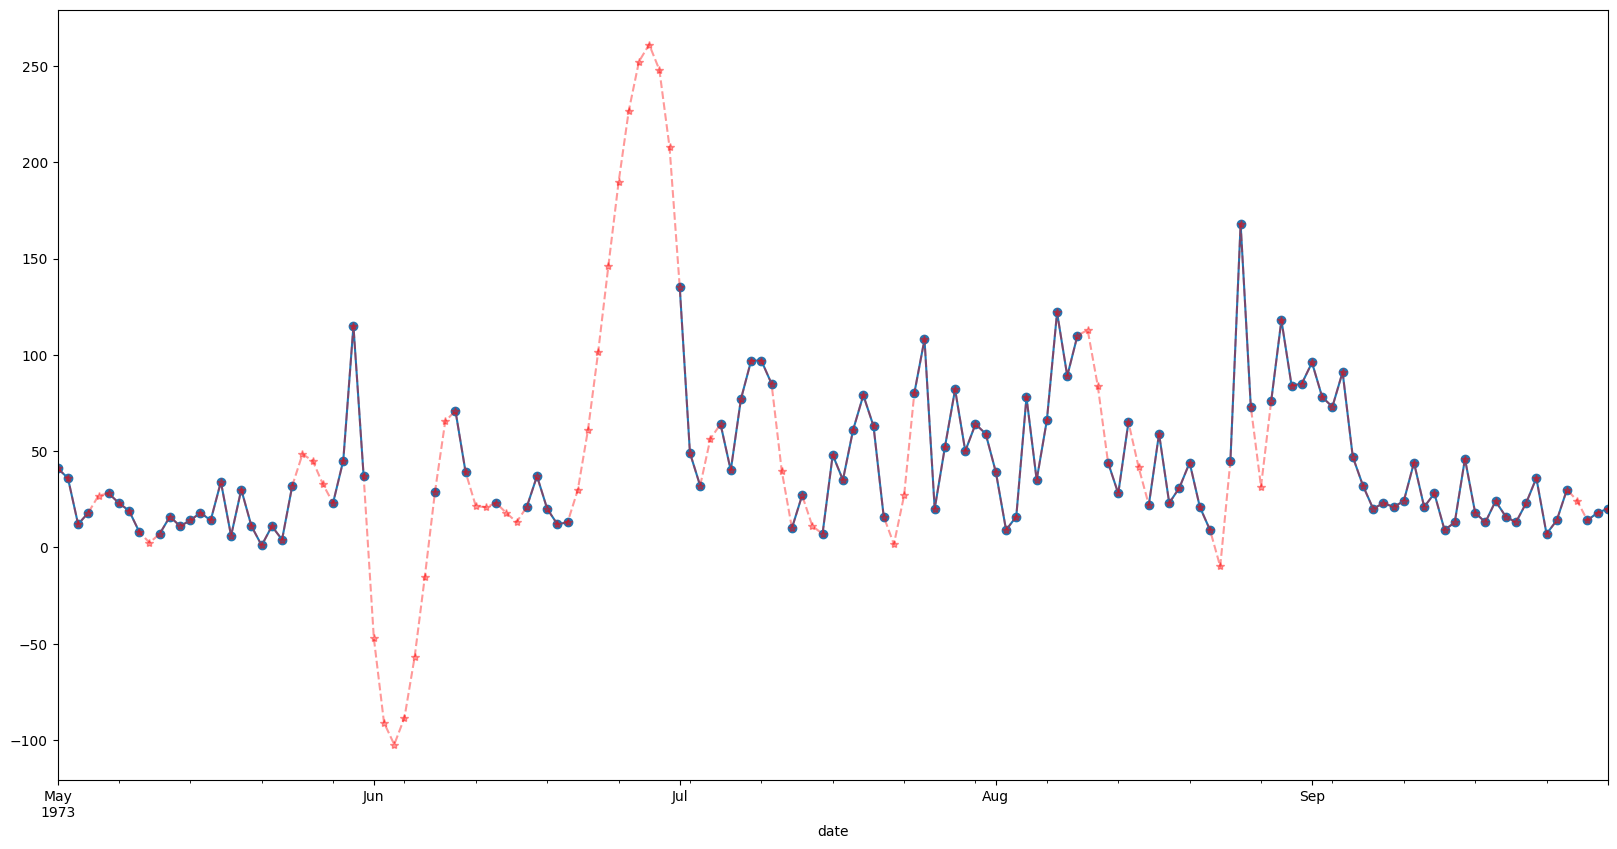

In [97]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.interpolate(
  method='polynomial',
  order=3
).plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()

### Interpolación Akima
Mantener las condiciones de estacionalidad de la serie

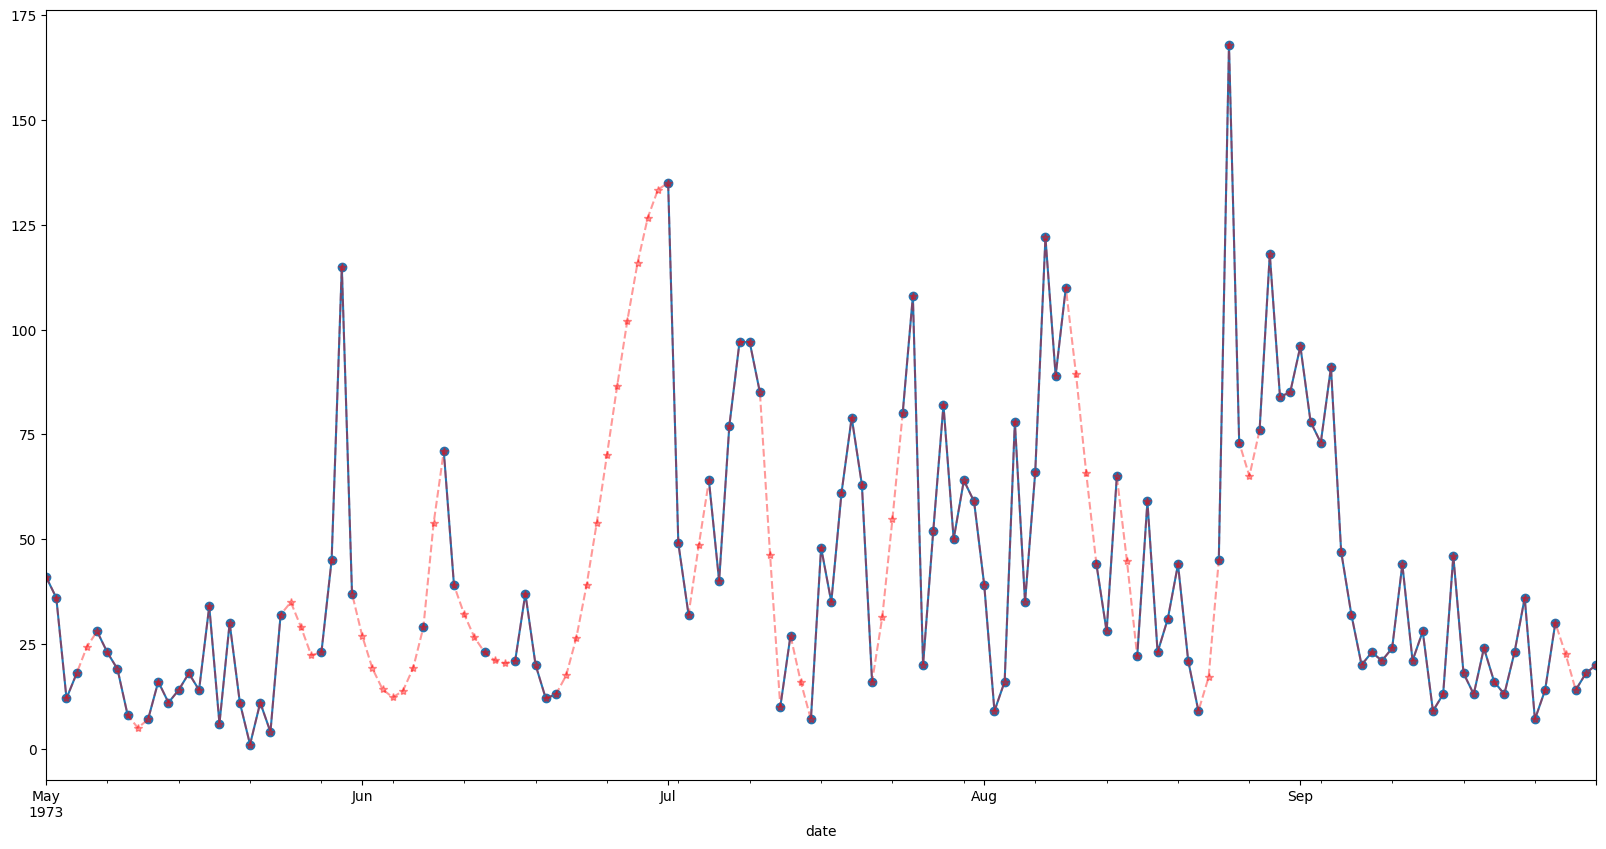

In [100]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.interpolate(
  method='akima',
).plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()

### Interpolación Pchip

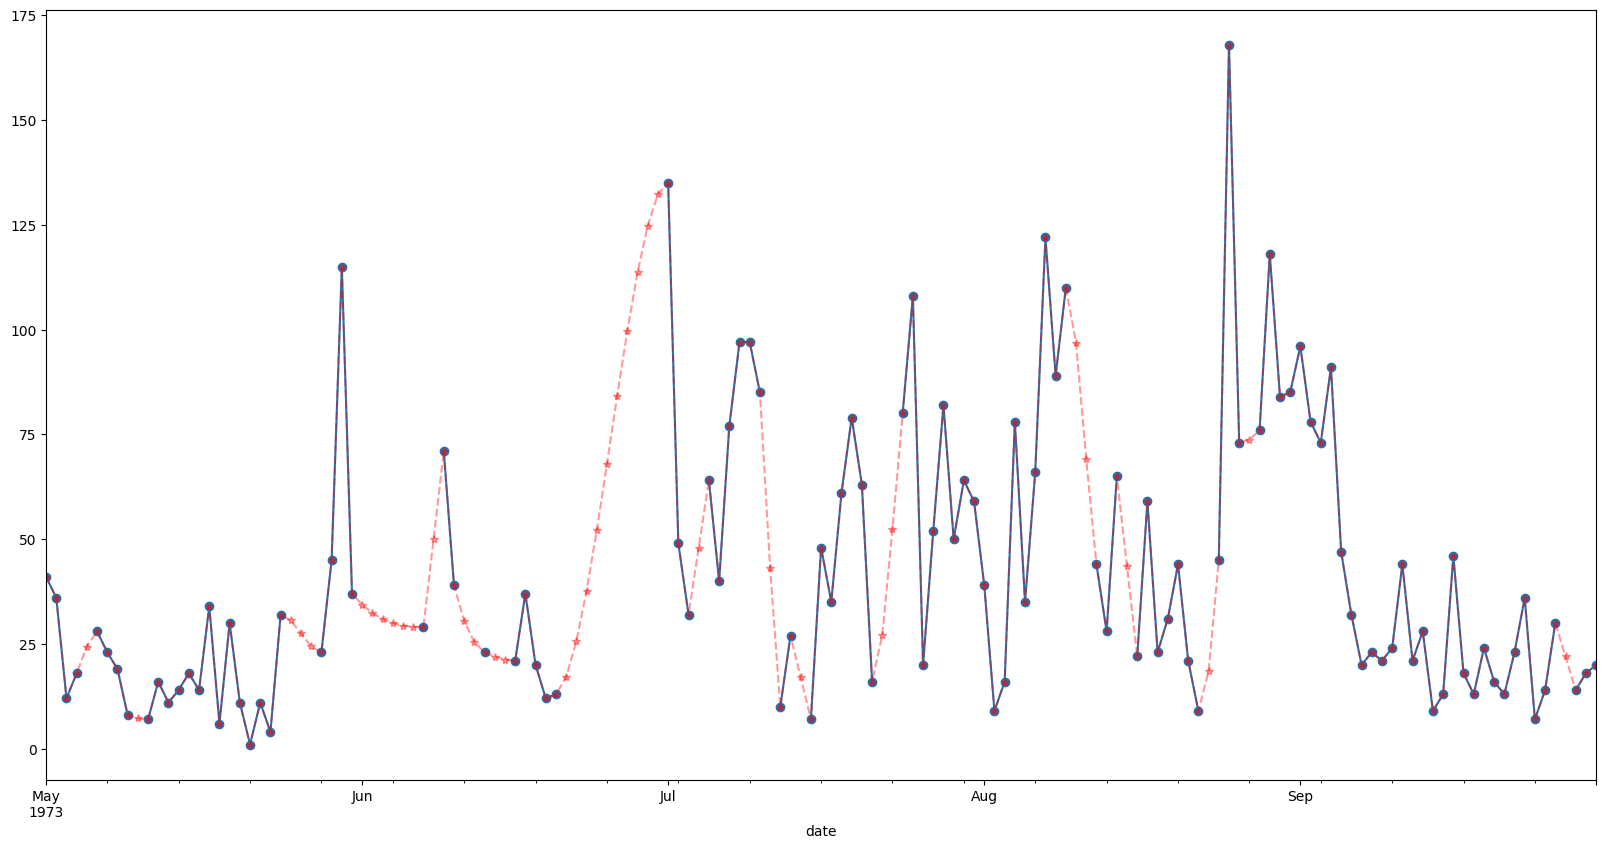

In [101]:
plt.figure(figsize=(20, 10))
airquality_df.ozone.plot(marker='o')
airquality_df.ozone.interpolate(
  method='pchip',
).plot(
  marker='*',
  color='r',
  alpha=0.4,
  ls='dashed'
)
plt.show()